In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import ElasticNetCV

warnings.filterwarnings('ignore')


In [ ]:
# Global function to calculate Sharpe ratio
def sharpe_ratio(returns):
    return np.mean(returns) / np.std(returns) if np.std(returns) != 0 else 0

# Load data
def load_data():
    """Load 100 portfolio data, handle column names and dates correctly"""
    # Read data, the first row as column names
    df = pd.read_csv("/content/Final_cleaned(in).csv", index_col=0)

    print(f"Original data shape: {df.shape}")
    print(f"Example original column names: {df.columns[:10].tolist()}")
    print(f"Example index: {df.index[:10].tolist()}")

    # Try different date formats
    try:
        # If in 'YYYYMMDD' format
        df.index = pd.to_datetime(df.index, format='%Y%m%d')
    except:
        try:
            # If in other formats
            df.index = pd.to_datetime(df.index)
        except:
            df.index = pd.to_datetime(df.index, errors='coerce')

    print(f"Converted date range: {df.index.min()} to {df.index.max()}")

    # Filter data after 2024-07-03
    start_date = '2024-07-03'
    df = df[df.index >= start_date]

    print(f"Filtered data time range: {df.index.min()} to {df.index.max()}")
    print(f"Filtered data shape: {df.shape}")

    # Check data volume for each year
    print("\nData volume statistics per year:")
    year_counts = df.index.year.value_counts().sort_index()
    print(year_counts)

    # Check specific date range for 2025
    df_2025 = df[df.index.year == 2025]
    if len(df_2025) > 0:
        print(f"\n2025 data range: {df_2025.index.min()} to {df_2025.index.max()}")
        print(f"Number of trading days in 2025: {len(df_2025)}")
        print(f"Sample of specific dates in 2025:")
        print(df_2025.index[:10].tolist())

    # Ensure we have 100 portfolios
    if df.shape[1] != 100:
        print(f"Warning: Data contains {df.shape[1]} columns, expected 100")
        if df.shape[1] > 100:
            df = df.iloc[:, :100]
            print(f"Taking the first 100 columns")

    # Convert to decimal percentage
    df = df / 100

    return df

In [ ]:
# Construct matrix N
def construct_N(p):
    """Construct transformation matrix N"""
    I = np.eye(p-1)
    ones = -np.ones((1, p-1))
    N = np.vstack([I, ones])
    return N

In [ ]:
def rolling_window_backtest(df, train_start, train_end, validation_start, validation_end):
    """Perform rolling window backtest"""

    # Get all dates in the validation period
    validation_dates = df.loc[validation_start:validation_end].index
    print(f"Number of days in validation period: {len(validation_dates)}")

    # Number of portfolios
    p = df.shape[1]

    # Equal-weighted portfolio weights
    w_ew = np.ones(p) / p

    # Construct matrix N
    N = construct_N(p)

    # Initialize results storage
    results = {
        'dates': [],
        'ew_returns': [],
        'minvar_returns': [],
        'lasso_returns': [],
        'ridge_returns': [],
        'elastic_returns': [],   # <-- new
        'blend_returns': [],     # <-- will be filled after backtest
        'ew_weights': [],
        'minvar_weights': [],
        'lasso_weights': [],
        'ridge_weights': [],
        'elastic_weights': [],   # <-- new
        'blend_weights': []      # <-- will be filled after backtest
    }

    # Initial training data (first window)
    current_train_data = df.loc[train_start:train_end]
    print(f"Initial training data shape: {current_train_data.shape}")

    # Rolling window backtest main loop
    for i, current_date in enumerate(validation_dates):
        R_train = current_train_data.values  # (126, p)
        R_test = df.loc[current_date].values  # Returns for current validation day

        results['dates'].append(current_date)

        # 1. Equal-weighted portfolio return
        ret_ew = np.dot(R_test, w_ew)
        results['ew_returns'].append(ret_ew)
        results['ew_weights'].append(w_ew.copy())

        # Construct y and X for regression
        y = R_train @ w_ew  # (126,)
        X = R_train @ N     # (126, p-1)

        # -------------------------
        # 2. OLS (MinVar approximation)
        # -------------------------
        try:
            X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
            beta_ols = np.linalg.pinv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y
            beta_ols = beta_ols[1:]
            w_minvar = w_ew - N @ beta_ols
            w_minvar = w_minvar / np.sum(w_minvar)
            ret_minvar = np.dot(R_test, w_minvar)

            results['minvar_returns'].append(ret_minvar)
            results['minvar_weights'].append(w_minvar)
        except Exception as e:
            print(f"OLS calculation error on {current_date}: {e}")
            results['minvar_returns'].append(ret_ew)
            results['minvar_weights'].append(w_ew.copy())

        # -------------------------
        # 3. LASSO
        # -------------------------
        try:
            lasso = LassoCV(
                alphas=np.logspace(-8, 8, 21),
                cv=5,
                random_state=42,
                max_iter=10000,
                fit_intercept=True
            )
            lasso.fit(X, y)
            beta_lasso = lasso.coef_
            w_lasso = w_ew - N @ beta_lasso
            w_lasso = w_lasso / np.sum(w_lasso)
            ret_lasso = np.dot(R_test, w_lasso)

            results['lasso_returns'].append(ret_lasso)
            results['lasso_weights'].append(w_lasso)
        except Exception as e:
            print(f"LASSO calculation error on {current_date}: {e}")
            results['lasso_returns'].append(ret_ew)
            results['lasso_weights'].append(w_ew.copy())

        # -------------------------
        # 4. Ridge
        # -------------------------
        try:
            ridge = RidgeCV(
                alphas=np.logspace(-8, 8, 21),
                cv=5,
                fit_intercept=True
            )
            ridge.fit(X, y)
            beta_ridge = ridge.coef_
            w_ridge = w_ew - N @ beta_ridge
            w_ridge = w_ridge / np.sum(w_ridge)
            ret_ridge = np.dot(R_test, w_ridge)

            results['ridge_returns'].append(ret_ridge)
            results['ridge_weights'].append(w_ridge)
        except Exception as e:
            print(f"Ridge calculation error on {current_date}: {e}")
            results['ridge_returns'].append(ret_ew)
            results['ridge_weights'].append(w_ew.copy())

        # -------------------------
        # 5. Elastic Net (new model)
        # -------------------------
        try:
            elastic = ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                alphas=np.logspace(-8, 8, 21),
                cv=5,
                max_iter=10000,
                fit_intercept=True,
                random_state=42
            )
            elastic.fit(X, y)
            beta_elastic = elastic.coef_
            w_elastic = w_ew - N @ beta_elastic
            w_elastic = w_elastic / np.sum(w_elastic)
            ret_elastic = np.dot(R_test, w_elastic)

            results['elastic_returns'].append(ret_elastic)
            results['elastic_weights'].append(w_elastic)
        except Exception as e:
            print(f"ElasticNet error on {current_date}: {e}")
            results['elastic_returns'].append(ret_ew)
            results['elastic_weights'].append(w_ew.copy())

        # -------------------------
        # Update rolling training window
        # -------------------------
        if i < len(validation_dates) - 1:
            current_train_data = current_train_data.iloc[1:]
            new_day = df.loc[current_date:current_date]
            current_train_data = pd.concat([current_train_data, new_day])

        if (i + 1) % 20 == 0:
            print(f"Completed {i+1}/{len(validation_dates)} days")

    return results


In [ ]:
def evaluate_performance_extended(results):
    """Evaluate portfolio performance for all available models"""

    def total_return(returns):
        return np.prod(1 + returns) - 1

    def max_drawdown(returns):
        cumulative = np.cumprod(1 + returns)
        peak = np.maximum.accumulate(cumulative)
        drawdown = (peak - cumulative) / peak
        return np.max(drawdown)

    metrics = {}
    mapping = {
        'EW': 'ew_returns',
        'MinVar': 'minvar_returns',
        'LASSO': 'lasso_returns',
        'Ridge': 'ridge_returns',
        'Elastic': 'elastic_returns',
        'Blend': 'blend_returns'
    }

    for name, key in mapping.items():
        if key not in results or len(results[key]) == 0:
            continue
        returns = np.array(results[key])
        metrics[name] = {
            'Sharpe Ratio': sharpe_ratio(returns),
            'Total Return': total_return(returns),
            'Mean Return': np.mean(returns),
            'Std Return': np.std(returns),
            'Max Drawdown': max_drawdown(returns)
        }

    return metrics


def print_metrics_table(metrics):
    print("\n=== Performance Summary ===")
    for name, m in metrics.items():
        print(f"\n{name}:")
        print(f"  Sharpe Ratio: {m['Sharpe Ratio']:.4f}")
        print(f"  Total Return: {m['Total Return']:.4f}")
        print(f"  Mean Daily Return: {m['Mean Return']:.6f}")
        print(f"  Std Daily Return: {m['Std Return']:.6f}")
        print(f"  Max Drawdown: {m['Max Drawdown']:.4f}")


In [ ]:
def tune_and_add_blend(results, df, base='ridge', gamma_grid=None):
    """
    Shrink Ridge (or LASSO/Elastic) weights toward Equal Weight.
    Chooses gamma that maximizes Sharpe ratio on validation returns.
    """
    if gamma_grid is None:
        gamma_grid = np.linspace(0.0, 1.0, 21)

    base_weights_key = f'{base}_weights'
    if base_weights_key not in results:
        raise ValueError(f"{base_weights_key} not in results. Run backtest first.")

    dates = results['dates']
    base_weights_list = results[base_weights_key]
    p = len(base_weights_list[0])
    w_ew = np.ones(p) / p

    best_gamma = None
    best_sharpe = -np.inf
    best_returns = None
    best_weights = None

    for gamma in gamma_grid:
        ret_list, wlist = [], []
        for date, w_base in zip(dates, base_weights_list):
            w_blend = (1.0 - gamma) * w_ew + gamma * w_base
            w_blend = w_blend / np.sum(w_blend)
            R_test = df.loc[date].values
            ret_list.append(np.dot(R_test, w_blend))
            wlist.append(w_blend)
        rets = np.array(ret_list)
        s = sharpe_ratio(rets)
        if s > best_sharpe:
            best_sharpe = s
            best_gamma = gamma
            best_returns = ret_list
            best_weights = wlist

    results['blend_returns'] = best_returns
    results['blend_weights'] = best_weights

    return best_gamma, best_sharpe


In [ ]:
def visualize_results(results, metrics):
    """Visualize portfolio performance including Elastic and Blend"""

    dates = results['dates']
    returns_ew = np.array(results['ew_returns'])
    returns_minvar = np.array(results['minvar_returns'])
    returns_lasso = np.array(results['lasso_returns'])
    returns_ridge = np.array(results['ridge_returns'])
    returns_elastic = np.array(results['elastic_returns'])
    returns_blend = np.array(results['blend_returns'])

    # Create figures
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Cumulative Returns
    cum_ew = np.cumprod(1 + returns_ew)
    cum_minvar = np.cumprod(1 + returns_minvar)
    cum_lasso = np.cumprod(1 + returns_lasso)
    cum_ridge = np.cumprod(1 + returns_ridge)
    cum_elastic = np.cumprod(1 + returns_elastic)
    cum_blend = np.cumprod(1 + returns_blend)

    ax1.plot(dates, cum_ew, label=f'EW (Sharpe: {metrics["EW"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_minvar, label=f'MinVar (Sharpe: {metrics["MinVar"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_lasso, label=f'LASSO (Sharpe: {metrics["LASSO"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_ridge, label=f'Ridge (Sharpe: {metrics["Ridge"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_elastic, label=f'Elastic (Sharpe: {metrics["Elastic"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_blend, label=f'Blend (Sharpe: {metrics["Blend"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.legend()
    ax1.set_title('Cumulative Returns Comparison - Validation Period (2025-01-02 to 2025-06-30)')
    ax1.set_ylabel('Cumulative Return')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

    # 2. Daily Returns Distribution
    ax2.hist(returns_ew, bins=50, alpha=0.5, label='EW', density=True)
    ax2.hist(returns_minvar, bins=50, alpha=0.5, label='MinVar', density=True)
    ax2.hist(returns_lasso, bins=50, alpha=0.5, label='LASSO', density=True)
    ax2.hist(returns_ridge, bins=50, alpha=0.5, label='Ridge', density=True)
    ax2.hist(returns_elastic, bins=50, alpha=0.5, label='Elastic', density=True)
    ax2.hist(returns_blend, bins=50, alpha=0.5, label='Blend', density=True)
    ax2.legend()
    ax2.set_title('Daily Returns Distribution')
    ax2.set_xlabel('Daily Return Rate')
    ax2.set_ylabel('Density')
    ax2.grid(True, alpha=0.3)

    # 3. Rolling Sharpe Ratio (30-day window)
    window_size = 30
    rolling_sharpe = lambda ret: [sharpe_ratio(ret[max(0, i-window_size+1):i+1]) for i in range(len(ret))]

    ax3.plot(dates, rolling_sharpe(returns_ew), label='EW', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_minvar), label='MinVar', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_lasso), label='LASSO', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_ridge), label='Ridge', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_elastic), label='Elastic', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_blend), label='Blend', linewidth=2)
    ax3.legend()
    ax3.set_title('Rolling Sharpe Ratio (30-day window)')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)

    # 4. Weight Distribution (Last day's weights)
    last_weights_keys = ['ew_weights', 'minvar_weights', 'lasso_weights', 'ridge_weights', 'elastic_weights', 'blend_weights']
    last_weights_names = ['EW', 'MinVar', 'LASSO', 'Ridge', 'Elastic', 'Blend']
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

    for lw, name, color in zip(last_weights_keys, last_weights_names, colors):
        ax4.scatter(range(len(results[lw][-1])), results[lw][-1], alpha=0.6, label=name, s=10, color=color)

    ax4.legend()
    ax4.set_title('Portfolio Weight Distribution (Last Day)')
    ax4.set_xlabel('Asset Index')
    ax4.set_ylabel('Weight')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('portfolio_performance_extended.png', dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
def print_best_portfolio(metrics):
    """Print the portfolio with the highest Sharpe Ratio"""
    best_name = None
    best_sharpe = -np.inf
    for name, m in metrics.items():
        if m['Sharpe Ratio'] > best_sharpe:
            best_sharpe = m['Sharpe Ratio']
            best_name = name

    print("\n=== Best Portfolio (Based on Sharpe Ratio) ===")
    print(f"Portfolio: {best_name}")
    print(f"Sharpe Ratio: {metrics[best_name]['Sharpe Ratio']:.4f}")
    print(f"Total Return: {metrics[best_name]['Total Return']:.4f}")
    print(f"Mean Daily Return: {metrics[best_name]['Mean Return']:.6f}")
    print(f"Std Daily Return: {metrics[best_name]['Std Return']:.6f}")
    print(f"Max Drawdown: {metrics[best_name]['Max Drawdown']:.4f}")


In [ ]:
# New visualization: Overfitting Mitigation Comparison
def visualize_overfitting_comparison(results, metrics):
    """Visualize comparison of overfitting mitigation effects"""

    dates = results['dates']
    returns_ew = np.array(results['ew_returns'])
    returns_minvar = np.array(results['minvar_returns'])
    returns_lasso = np.array(results['lasso_returns'])
    returns_ridge = np.array(results['ridge_returns'])

    # Create figures
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. EW vs MinVar: Cumulative return comparison (showing overfitting problem)
    cum_ew = np.cumprod(1 + returns_ew)
    cum_minvar = np.cumprod(1 + returns_minvar)

    ax1.plot(dates, cum_ew, label=f'EW (Sharpe: {metrics["EW"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='blue', alpha=0.8)
    ax1.plot(dates, cum_minvar, label=f'MinVar (Sharpe: {metrics["MinVar"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='red', alpha=0.8)
    ax1.legend(fontsize=12)
    ax1.set_title('EW vs MinVar: Cumulative Return Comparison\n(Showing MinVar Overfitting Problem)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Cumulative Return', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=1, color='black', linestyle='--', alpha=0.5)

    # 2. LASSO vs Ridge: Cumulative return comparison (showing regularization effect)
    cum_lasso = np.cumprod(1 + returns_lasso)
    cum_ridge = np.cumprod(1 + returns_ridge)

    ax2.plot(dates, cum_lasso, label=f'LASSO (Sharpe: {metrics["LASSO"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='green', alpha=0.8)
    ax2.plot(dates, cum_ridge, label=f'Ridge (Sharpe: {metrics["Ridge"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='orange', alpha=0.8)
    ax2.legend(fontsize=12)
    ax2.set_title('LASSO vs Ridge: Cumulative Return Comparison\n(Showing Regularization Mitigating Overfitting)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Cumulative Return', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)

    # 3. Volatility Comparison (showing risk control effect)
    window_size = 20
    vol_ew = pd.Series(returns_ew).rolling(window=window_size).std().values
    vol_minvar = pd.Series(returns_minvar).rolling(window=window_size).std().values
    vol_lasso = pd.Series(returns_lasso).rolling(window=window_size).std().values
    vol_ridge = pd.Series(returns_ridge).rolling(window=window_size).std().values

    ax3.plot(dates[window_size-1:], vol_ew[window_size-1:], label='EW', linewidth=2, color='blue')
    ax3.plot(dates[window_size-1:], vol_minvar[window_size-1:], label='MinVar', linewidth=2, color='red')
    ax3.plot(dates[window_size-1:], vol_lasso[window_size-1:], label='LASSO', linewidth=2, color='green')
    ax3.plot(dates[window_size-1:], vol_ridge[window_size-1:], label='Ridge', linewidth=2, color='orange')
    ax3.legend()
    ax3.set_title('Rolling Volatility Comparison (20-day window)\nLASSO/Ridge Achieve Better Risk Control', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Volatility', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)

    # 4. Weight Stability Comparison (showing overfitting mitigation)
    # Calculate the standard deviation of weight changes (measure of weight stability)
    def calculate_weight_stability(weights_list):
        weights_array = np.array(weights_list)
        weight_std = np.std(weights_array, axis=0)
        return np.mean(weight_std)  # Mean standard deviation of weight changes

    stability_ew = calculate_weight_stability(results['ew_weights'])
    stability_minvar = calculate_weight_stability(results['minvar_weights'])
    stability_lasso = calculate_weight_stability(results['lasso_weights'])
    stability_ridge = calculate_weight_stability(results['ridge_weights'])

    stability_data = [stability_ew, stability_minvar, stability_lasso, stability_ridge]
    portfolio_names = ['EW', 'MinVar', 'LASSO', 'Ridge']
    colors = ['blue', 'red', 'green', 'orange']

    bars = ax4.bar(portfolio_names, stability_data, color=colors, alpha=0.7)
    ax4.set_title('Weight Stability Comparison\n(Mean Standard Deviation of Weight Changes)\nLower = More Stable, Mitigating Overfitting', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Mean Standard Deviation of Weight Changes', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='y')

    # Add value labels to the bars
    for bar, value in zip(bars, stability_data):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('overfitting_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Additional analysis: Show how regularization affects weight distribution
    fig2, (ax5, ax6) = plt.subplots(1, 2, figsize=(15, 6))

    # Weight distribution comparison on the last day
    last_weights_minvar = results['minvar_weights'][-1]
    last_weights_lasso = results['lasso_weights'][-1]
    last_weights_ridge = results['ridge_weights'][-1]

    # MinVar weight distribution (potential overfitting)
    ax5.hist(last_weights_minvar, bins=30, alpha=0.7, color='red', label='MinVar')
    ax5.axvline(x=1/100, color='black', linestyle='--', label='Equal Weight Benchmark')
    ax5.set_title('MinVar Weight Distribution\n(May Show Extreme Weights, Signs of Overfitting)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Weight')
    ax5.set_ylabel('Frequency')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # LASSO/Ridge weight distribution (regularization effect)
    ax6.hist(last_weights_lasso, bins=30, alpha=0.7, color='green', label='LASSO')
    ax6.hist(last_weights_ridge, bins=30, alpha=0.7, color='orange', label='Ridge')
    ax6.axvline(x=1/100, color='black', linestyle='--', label='Equal Weight Benchmark')
    ax6.set_title('LASSO vs Ridge Weight Distribution\n(Regularization Makes Weights More Reasonable)', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Weight')
    ax6.set_ylabel('Frequency')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('weight_distribution_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print overfitting analysis results
    print("\n=== Overfitting Mitigation Analysis ===")
    print(f"MinVar Sharpe Ratio: {metrics['MinVar']['Sharpe Ratio']:.4f} (Potential Overfitting)")
    print(f"LASSO Sharpe Ratio: {metrics['LASSO']['Sharpe Ratio']:.4f} (Improvement {metrics['LASSO']['Sharpe Ratio'] - metrics['MinVar']['Sharpe Ratio']:.4f})")
    print(f"Ridge Sharpe Ratio: {metrics['Ridge']['Sharpe Ratio']:.4f} (Improvement {metrics['Ridge']['Sharpe Ratio'] - metrics['MinVar']['Sharpe Ratio']:.4f})")

    print(f"\nVolatility Control:")
    print(f"MinVar Volatility: {metrics['MinVar']['Std Return']:.4f}")
    print(f"LASSO Volatility: {metrics['LASSO']['Std Return']:.4f} (Reduced by {(1 - metrics['LASSO']['Std Return']/metrics['MinVar']['Std Return'])*100:.1f}%)")
    print(f"Ridge Volatility: {metrics['Ridge']['Std Return']:.4f} (Reduced by {(1 - metrics['Ridge']['Std Return']/metrics['MinVar']['Std Return'])*100:.1f}%)")

    print(f"\nWeight Stability (Mean Std Dev):")
    print(f"EW: {stability_ew:.6f}")
    print(f"MinVar: {stability_minvar:.6f}")
    print(f"LASSO: {stability_lasso:.6f} (Improved by {(1 - stability_lasso/stability_minvar)*100:.1f}%)")
    print(f"Ridge: {stability_ridge:.6f} (Improved by {(1 - stability_ridge/stability_minvar)*100:.1f}%)")



In [ ]:
def main():
    print("=== Portfolio Optimization Project ===")

    # 1. Load Data
    print("\n1. Loading Data...")
    df = load_data()

    # 2a. Validation Set Backtest
    print("\n2a. Performing Validation Backtest...")
    results_val = rolling_window_backtest(
        df,
        train_start='2024-07-03',
        train_end='2024-12-31',
        validation_start='2025-01-02',
        validation_end='2025-06-30'
    )

    print("\n3a. Evaluating Validation Performance...")
    #metrics_val = evaluate_performance(results_val)
    metrics_val = evaluate_performance_extended(results_val)
    print("\n=== Validation Performance (2025-01-02 to 2025-06-30) ===")
    for portfolio, metric in metrics_val.items():
        print(f"\n{portfolio}:")
        print(f"  Sharpe Ratio: {metric['Sharpe Ratio']:.4f}")
        print(f"  Total Return: {metric['Total Return']:.4f}")
        print(f"  Average Daily Return: {metric['Mean Return']:.4f}")
        print(f"  Daily Return Standard Deviation: {metric['Std Return']:.4f}")
        print(f"  Maximum Drawdown: {metric['Max Drawdown']:.4f}")

    # ----------------------------
    # Add Blend model (shrink Ridge toward EW)
    # ----------------------------
    best_gamma, best_sharpe = tune_and_add_blend(results_val, df, base='ridge')
    print(f"\nBest Blend gamma (Ridge→EW): {best_gamma:.3f}, Sharpe: {best_sharpe:.4f}")

    # Recompute metrics now that Blend exists
    metrics_val = evaluate_performance_extended(results_val)
    print_metrics_table(metrics_val)

    # 4a. Generating Validation Visualization Charts...
    visualize_results(results_val, metrics_val)
    visualize_overfitting_comparison(results_val, metrics_val)

    print ("===============================================")
    print("\n3a. Evaluating Validation Performance...")

    # ===========================
    # 2b. Final Test Set Backtest
    # currently commented out because dataset ends at 2025-06-30.
    # pls uncomment this block when August 2025 data is available.
    #
    # print("\n2b. Performing Final Test Backtest...")
    # results_test = rolling_window_backtest(
    #     df,
    #     train_start='2025-02-03',
    #     train_end='2025-07-31',
    #     validation_start='2025-08-01',
    #     validation_end='2025-08-30'
    # )
    #
    # print("\n3b. Evaluating Final Test Performance...")
    # metrics_test = evaluate_performance_extended(results_test)
    # print("\n=== Final Test Performance (2025-08-01 to 2025-08-30) ===")
    # for portfolio, metric in metrics_test.items():
    #     print(f"\n{portfolio}:")
    #     print(f"  Sharpe Ratio: {metric['Sharpe Ratio']:.4f}")
    #     print(f"  Total Return: {metric['Total Return']:.4f}")
    #     print(f"  Average Daily Return: {metric['Mean Return']:.4f}")
    #     print(f"  Daily Return Standard Deviation: {metric['Std Return']:.4f}")
    #     print(f"  Maximum Drawdown: {metric['Max Drawdown']:.4f}")
    #
    # print("\n4b. Generating Final Test Visualization Charts...")
    # visualize_results(results_test, metrics_test)
    # visualize_overfitting_comparison(results_test, metrics_test)
    #
    # # Save results for test set
    # results_df = pd.DataFrame({
    #     'Date': results_test['dates'],
    #     'EW_Return': results_test['ew_returns'],
    #     'MinVar_Return': results_test['minvar_returns'],
    #     'LASSO_Return': results_test['lasso_returns'],
    #     'Ridge_Return': results_test['ridge_returns']
    # })
    # results_df.to_csv('portfolio_returns_final_test.csv', index=False)
    # print("\nFinal Test Results saved to portfolio_returns_final_test.csv")
    # ===========================

    print_best_portfolio(metrics_val)  # <-- prints best Sharpe ratio portfolio

    visualize_results(results_val, metrics_val)  # includes Elastic and Blend now
    visualize_overfitting_comparison(results_val, metrics_val)

    print("\n=== Project Completed ===")
    return df, results_val


=== Portfolio Optimization Project ===

1. Loading Data...
Original data shape: (15603, 100)
Example original column names: ['SMALL LoOP', 'ME1 OP2', 'ME1 OP3', 'ME1 OP4', 'ME1 OP5', 'ME1 OP6', 'ME1 OP7', 'ME1 OP8', 'ME1 OP9', 'SMALL HiOP']
Example index: ['7/1/1963', '7/2/1963', '7/3/1963', '7/5/1963', '7/8/1963', '7/9/1963', '7/10/1963', '7/11/1963', '7/12/1963', '7/15/1963']
Converted date range: 1963-07-01 00:00:00 to 2025-06-30 00:00:00
Filtered data time range: 2024-07-03 00:00:00 to 2025-06-30 00:00:00
Filtered data shape: (248, 100)

Data volume statistics per year:
Date
2024    126
2025    122
Name: count, dtype: int64

2025 data range: 2025-01-02 00:00:00 to 2025-06-30 00:00:00
Number of trading days in 2025: 122
Sample of specific dates in 2025:
[Timestamp('2025-01-02 00:00:00'), Timestamp('2025-01-03 00:00:00'), Timestamp('2025-01-06 00:00:00'), Timestamp('2025-01-07 00:00:00'), Timestamp('2025-01-08 00:00:00'), Timestamp('2025-01-10 00:00:00'), Timestamp('2025-01-13 00:00:

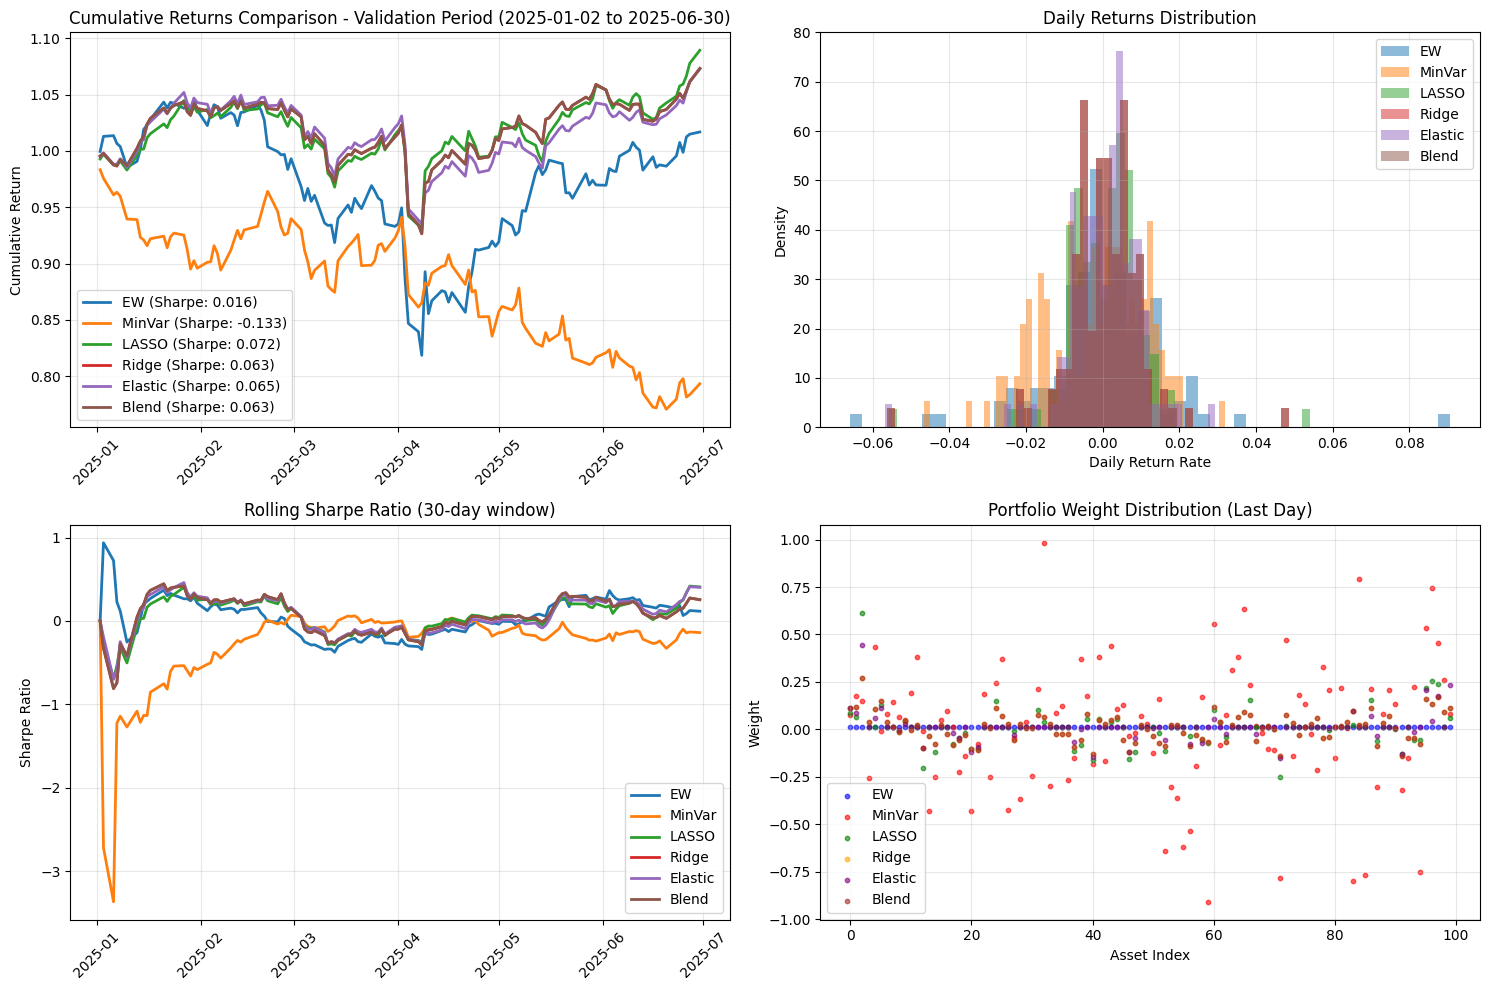

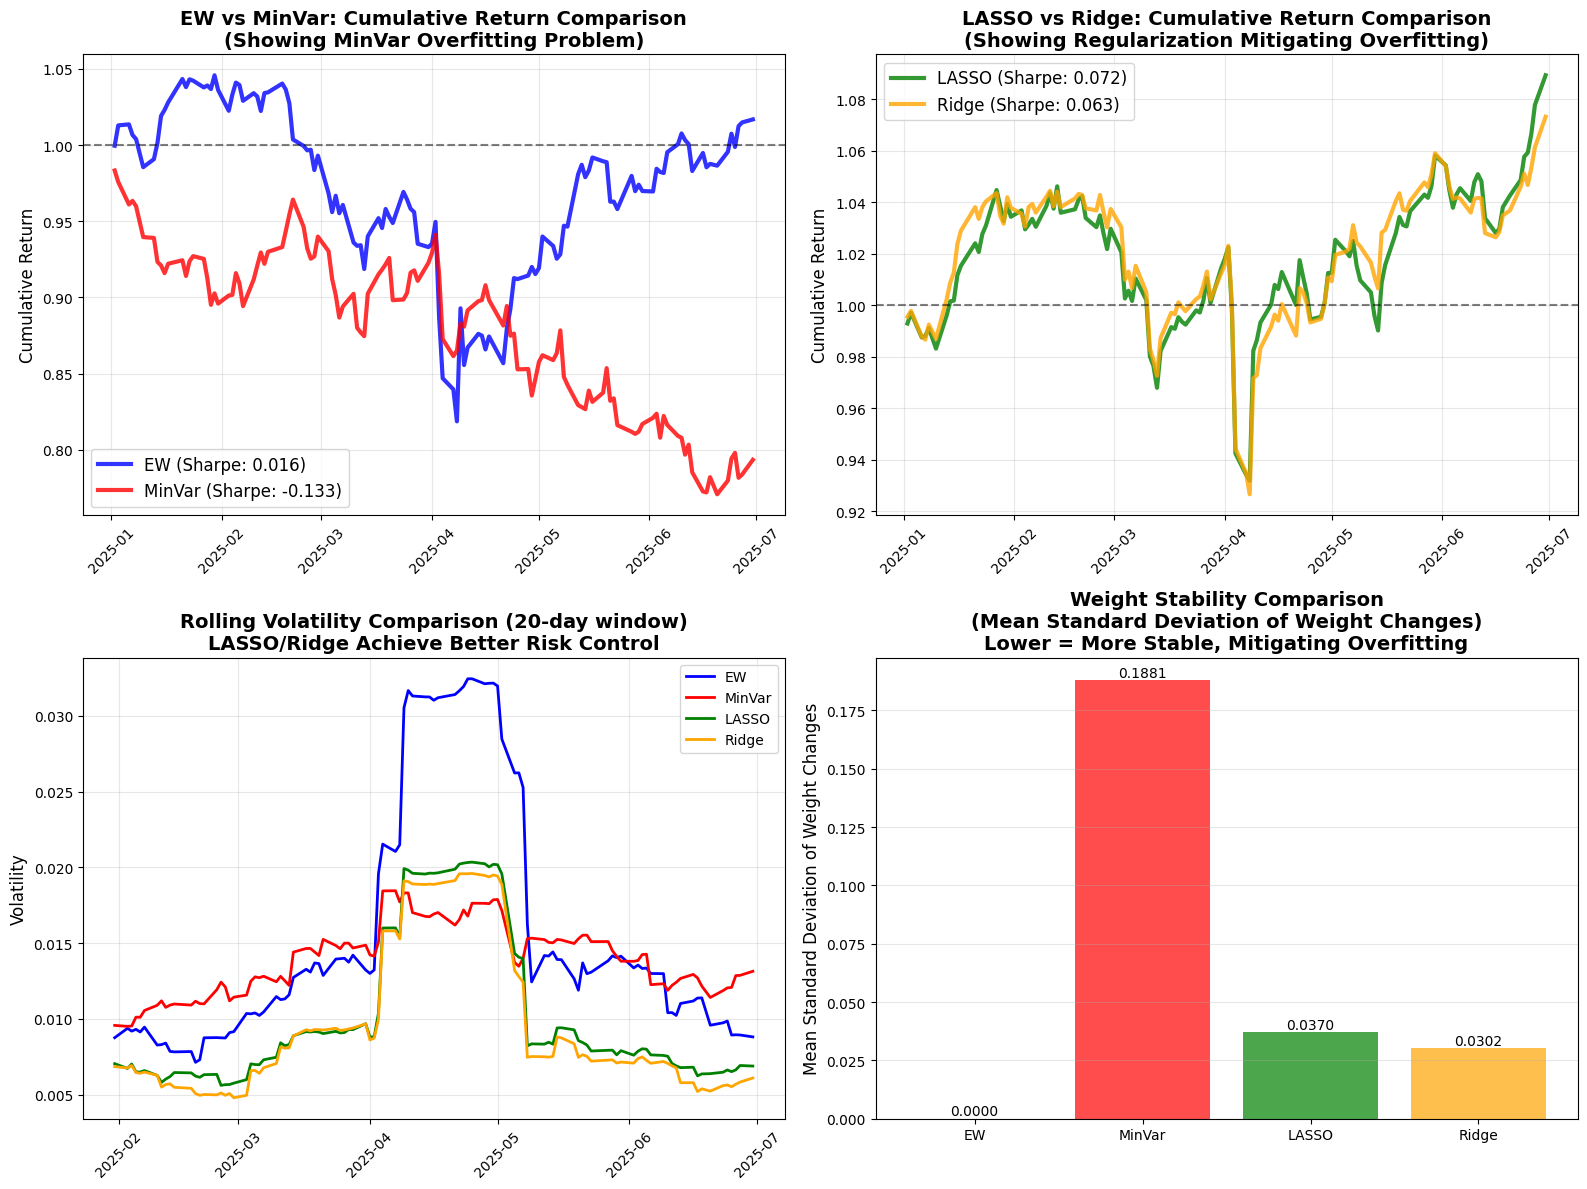

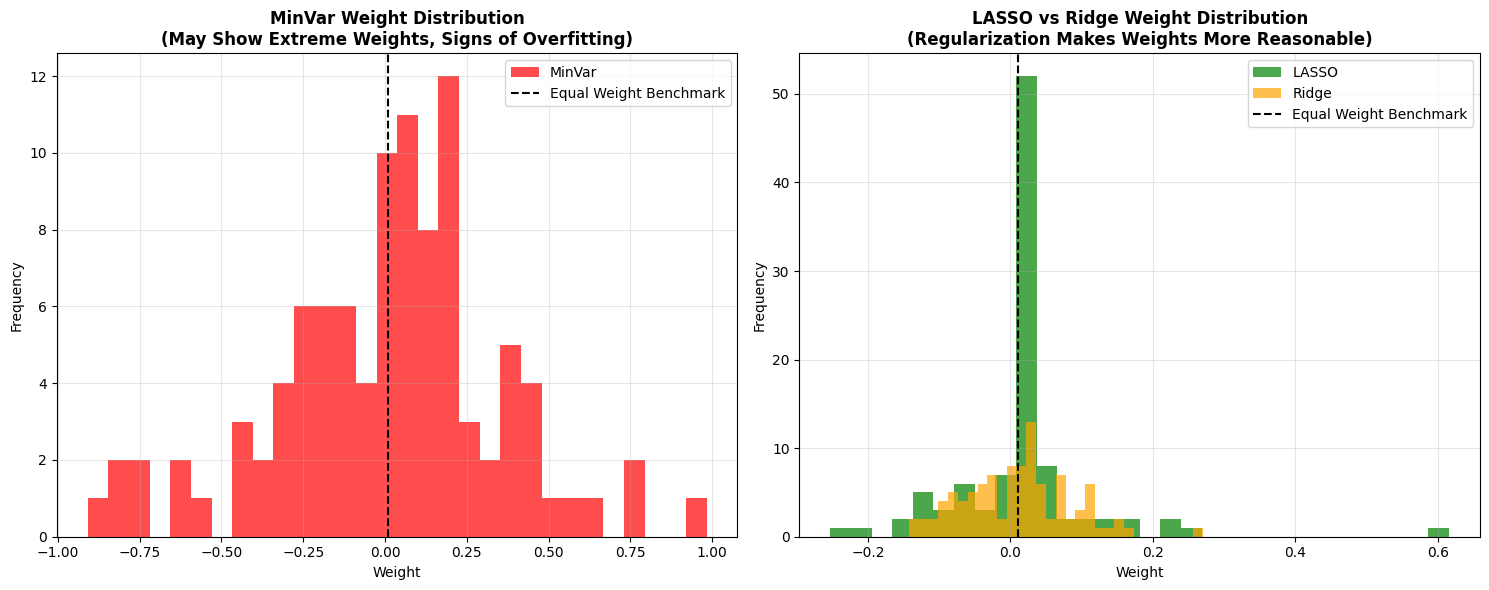


=== Overfitting Mitigation Analysis ===
MinVar Sharpe Ratio: -0.1327 (Potential Overfitting)
LASSO Sharpe Ratio: 0.0722 (Improvement 0.2049)
Ridge Sharpe Ratio: 0.0629 (Improvement 0.1956)

Volatility Control:
MinVar Volatility: 0.0136
LASSO Volatility: 0.0105 (Reduced by 22.8%)
Ridge Volatility: 0.0100 (Reduced by 26.3%)

Weight Stability (Mean Std Dev):
EW: 0.000000
MinVar: 0.188149
LASSO: 0.037028 (Improved by 80.3%)
Ridge: 0.030225 (Improved by 83.9%)

3a. Evaluating Validation Performance...

=== Best Portfolio (Based on Sharpe Ratio) ===
Portfolio: LASSO
Sharpe Ratio: 0.0722
Total Return: 0.0893
Mean Daily Return: 0.000757
Std Daily Return: 0.010484
Max Drawdown: 0.1093


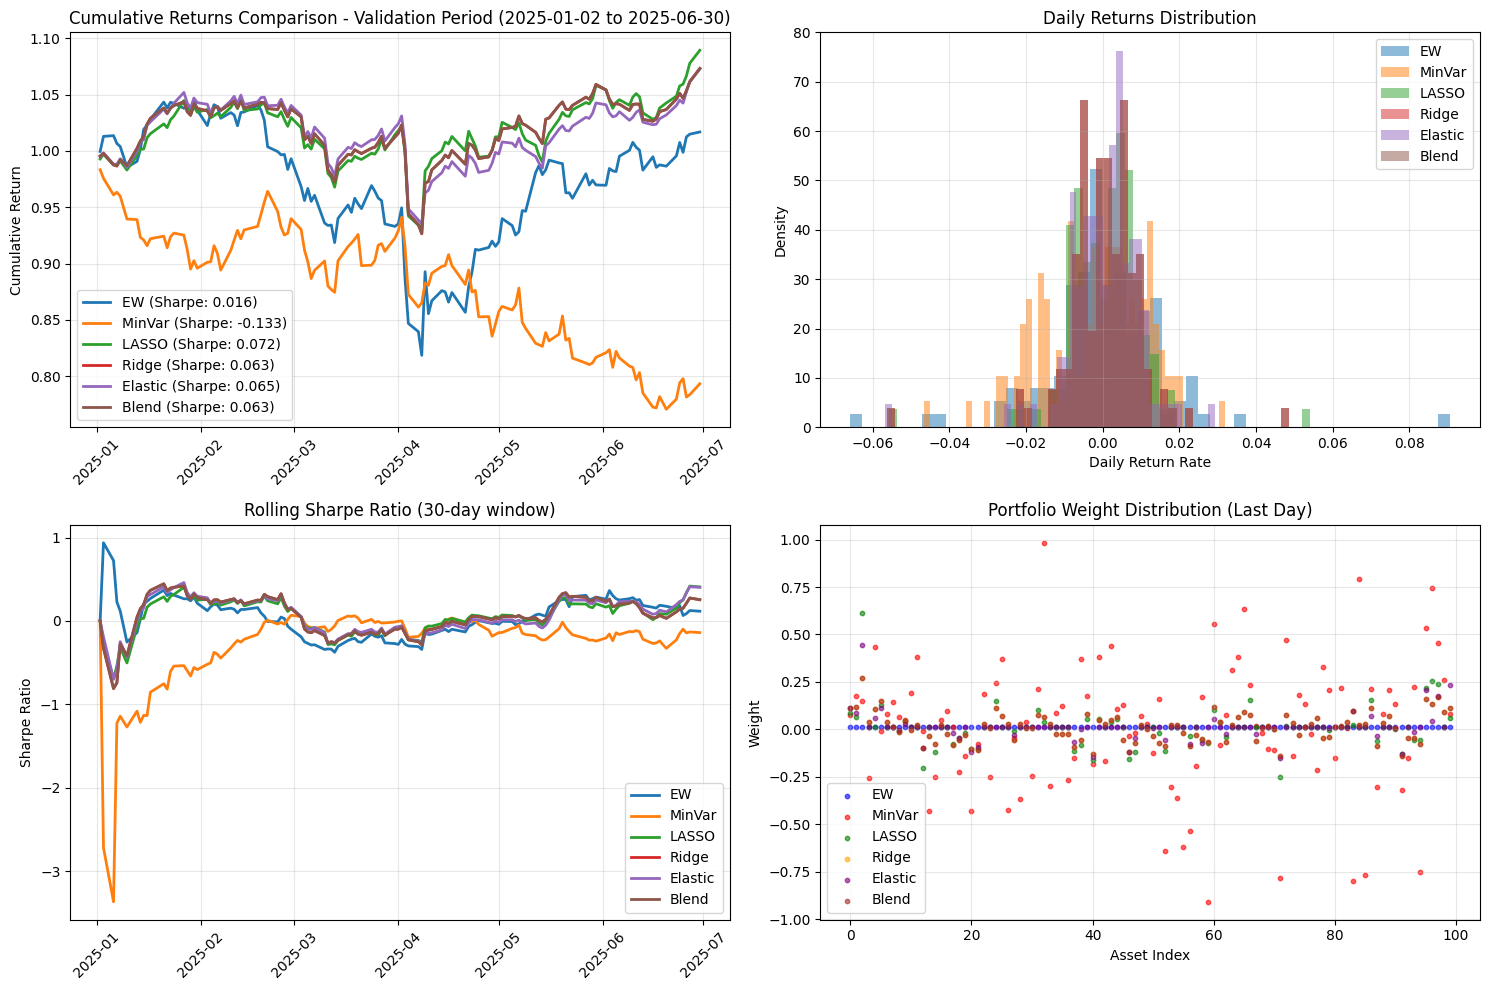

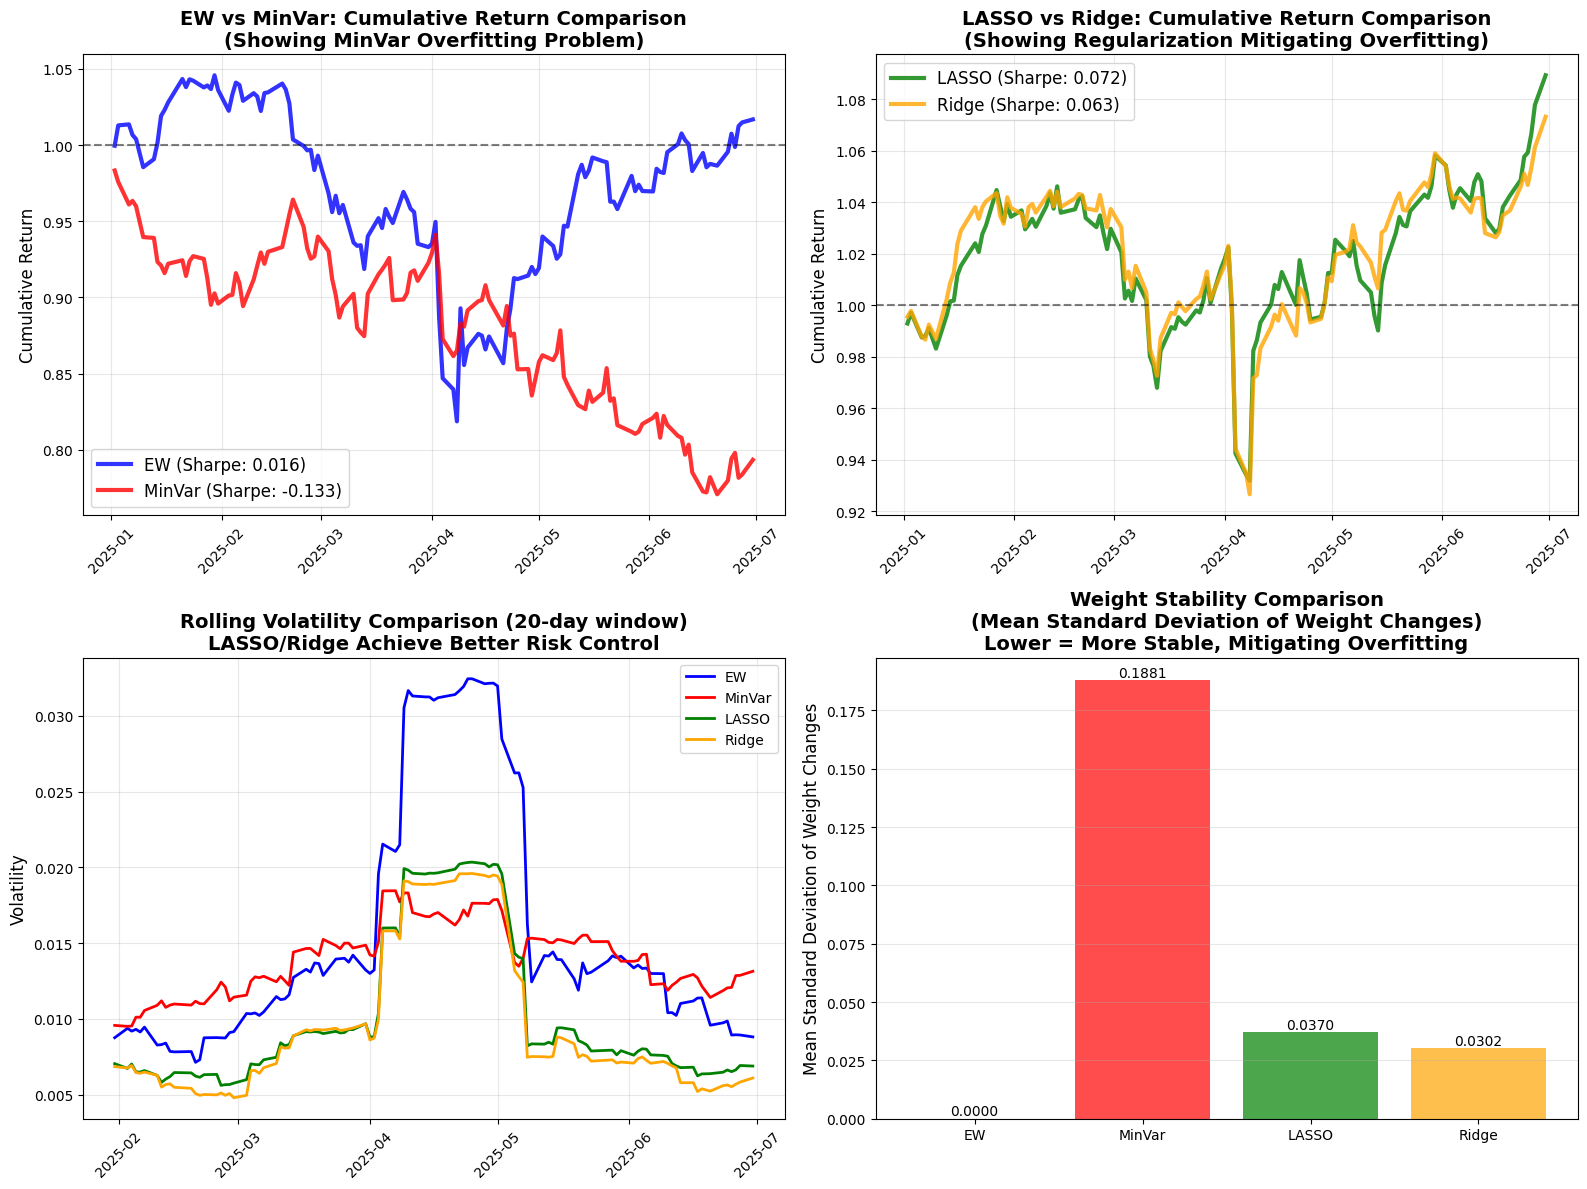

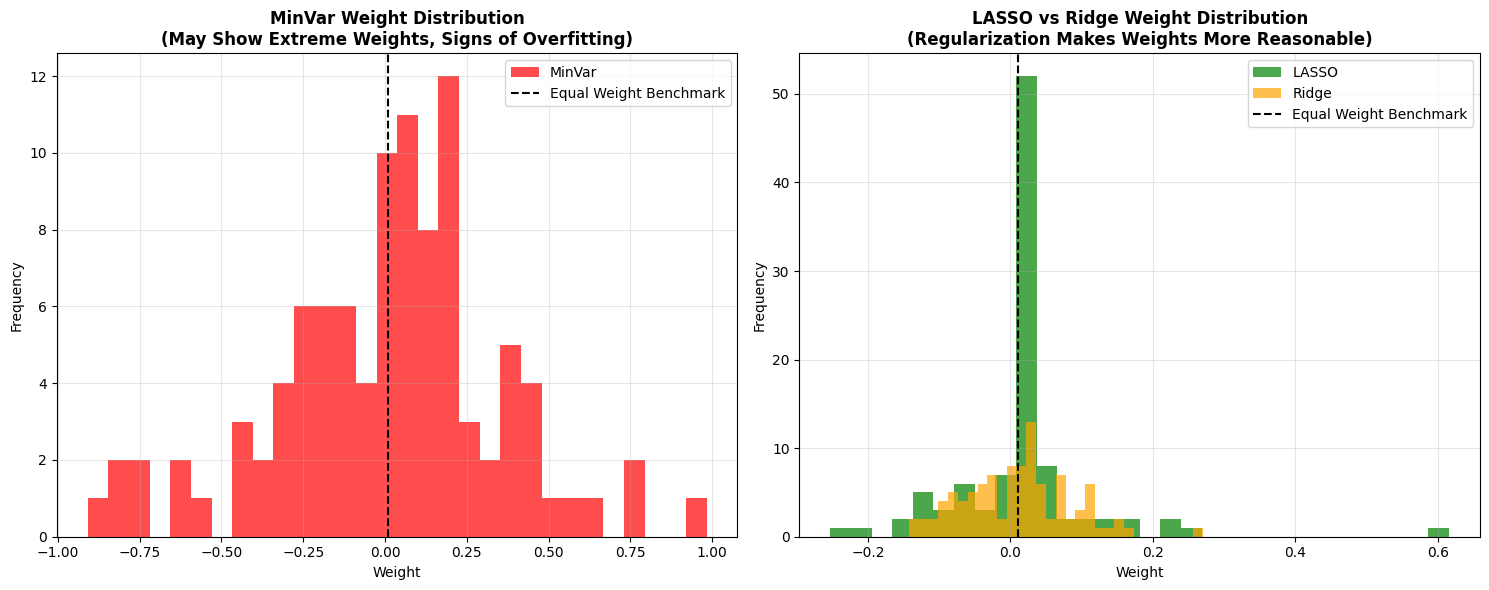


=== Overfitting Mitigation Analysis ===
MinVar Sharpe Ratio: -0.1327 (Potential Overfitting)
LASSO Sharpe Ratio: 0.0722 (Improvement 0.2049)
Ridge Sharpe Ratio: 0.0629 (Improvement 0.1956)

Volatility Control:
MinVar Volatility: 0.0136
LASSO Volatility: 0.0105 (Reduced by 22.8%)
Ridge Volatility: 0.0100 (Reduced by 26.3%)

Weight Stability (Mean Std Dev):
EW: 0.000000
MinVar: 0.188149
LASSO: 0.037028 (Improved by 80.3%)
Ridge: 0.030225 (Improved by 83.9%)

=== Project Completed ===


In [ ]:
if __name__ == "__main__":
    main()

# Enhancing Model Focus on Recent Data through Instance Weighting

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV
import matplotlib.pyplot as plt
import warnings
from sklearn.linear_model import ElasticNetCV

warnings.filterwarnings('ignore')

In [2]:
# Global function to calculate Sharpe ratio
def sharpe_ratio(returns):
    return np.mean(returns) / np.std(returns) if np.std(returns) != 0 else 0

# Load data
def load_data():
    """Load 100 portfolio data, handle column names and dates correctly"""
    # Read data, the first row as column names
    df = pd.read_csv("Final_cleaned.csv", index_col=0)

    print(f"Original data shape: {df.shape}")
    print(f"Example original column names: {df.columns[:10].tolist()}")
    print(f"Example index: {df.index[:10].tolist()}")

    # Try different date formats
    try:
        # If in 'YYYYMMDD' format
        df.index = pd.to_datetime(df.index, format='%Y%m%d')
    except:
        try:
            # If in other formats
            df.index = pd.to_datetime(df.index)
        except:
            df.index = pd.to_datetime(df.index, errors='coerce')

    print(f"Converted date range: {df.index.min()} to {df.index.max()}")

    # Filter data after 2024-07-03
    start_date = '2024-07-03'
    df = df[df.index >= start_date]

    print(f"Filtered data time range: {df.index.min()} to {df.index.max()}")
    print(f"Filtered data shape: {df.shape}")

    # Check data volume for each year
    print("\nData volume statistics per year:")
    year_counts = df.index.year.value_counts().sort_index()
    print(year_counts)

    # Check specific date range for 2025
    df_2025 = df[df.index.year == 2025]
    if len(df_2025) > 0:
        print(f"\n2025 data range: {df_2025.index.min()} to {df_2025.index.max()}")
        print(f"Number of trading days in 2025: {len(df_2025)}")
        print(f"Sample of specific dates in 2025:")
        print(df_2025.index[:10].tolist())

    # Ensure we have 100 portfolios
    if df.shape[1] != 100:
        print(f"Warning: Data contains {df.shape[1]} columns, expected 100")
        if df.shape[1] > 100:
            df = df.iloc[:, :100]
            print(f"Taking the first 100 columns")

    # Convert to decimal percentage
    df = df / 100

    return df

In [3]:

# Construct matrix N
def construct_N(p):
    """Construct transformation matrix N"""
    I = np.eye(p-1)
    ones = -np.ones((1, p-1))
    N = np.vstack([I, ones])
    return N

In [4]:
def create_time_weights(window_size, decay_factor=0.95):
    """
    Create time-based weights where recent days have higher weights
    Uses exponential decay: weight_i = decay_factor^(window_size - i)
    """
    weights = np.array([decay_factor ** (window_size - i - 1) for i in range(window_size)])
    weights = weights / np.sum(weights)  # Normalize to sum to 1
    return weights


In [5]:
def rolling_window_backtest(df, train_start, train_end, validation_start, validation_end, use_time_weights=True, decay_factor=0.95):
    """Perform rolling window backtest with optional time-based weighting"""

    # Get all dates in the validation period
    validation_dates = df.loc[validation_start:validation_end].index
    print(f"Number of days in validation period: {len(validation_dates)}")

    # Number of portfolios
    p = df.shape[1]

    # Equal-weighted portfolio weights
    w_ew = np.ones(p) / p

    # Construct matrix N
    N = construct_N(p)

    # Initialize results storage
    results = {
        'dates': [],
        'ew_returns': [],
        'minvar_returns': [],
        'lasso_returns': [],
        'ridge_returns': [],
        'elastic_returns': [],
        'blend_returns': [],
        'ew_weights': [],
        'minvar_weights': [],
        'lasso_weights': [],
        'ridge_weights': [],
        'elastic_weights': [],
        'blend_weights': []
    }

    # Initial training data (first window)
    current_train_data = df.loc[train_start:train_end]
    print(f"Initial training data shape: {current_train_data.shape}")
    
    if use_time_weights:
        window_size = len(current_train_data)
        time_weights = create_time_weights(window_size, decay_factor)
        print(f"Using time-based weights with decay factor {decay_factor}")
        print(f"Time weights (first 5, last 5): {time_weights[:5].round(4)} ... {time_weights[-5:].round(4)}")

    # Rolling window backtest main loop
    for i, current_date in enumerate(validation_dates):
        R_train = current_train_data.values  # (126, p)
        R_test = df.loc[current_date].values  # Returns for current validation day

        results['dates'].append(current_date)

        # 1. Equal-weighted portfolio return
        ret_ew = np.dot(R_test, w_ew)
        results['ew_returns'].append(ret_ew)
        results['ew_weights'].append(w_ew.copy())

        # Construct y and X for regression
        y = R_train @ w_ew  # (126,)
        X = R_train @ N     # (126, p-1)

        # Apply time-based weights if enabled
        if use_time_weights:
            # Create diagonal weight matrix
            W = np.diag(time_weights)
            # Apply weights to X and y
            X_weighted = W @ X
            y_weighted = W @ y
        else:
            X_weighted = X
            y_weighted = y

        # -------------------------
        # 2. OLS (MinVar approximation)
        # -------------------------
        try:
            if use_time_weights:
                # Weighted OLS
                X_with_intercept = np.column_stack([np.ones(X_weighted.shape[0]), X_weighted])
                W_sqrt = np.sqrt(np.diag(time_weights))
                X_weighted_sqrt = W_sqrt @ X_with_intercept
                y_weighted_sqrt = W_sqrt @ y_weighted
                beta_ols = np.linalg.pinv(X_weighted_sqrt.T @ X_weighted_sqrt) @ X_weighted_sqrt.T @ y_weighted_sqrt
            else:
                # Standard OLS
                X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
                beta_ols = np.linalg.pinv(X_with_intercept.T @ X_with_intercept) @ X_with_intercept.T @ y
            
            beta_ols = beta_ols[1:]
            w_minvar = w_ew - N @ beta_ols
            w_minvar = w_minvar / np.sum(w_minvar)
            ret_minvar = np.dot(R_test, w_minvar)

            results['minvar_returns'].append(ret_minvar)
            results['minvar_weights'].append(w_minvar)
        except Exception as e:
            print(f"OLS calculation error on {current_date}: {e}")
            results['minvar_returns'].append(ret_ew)
            results['minvar_weights'].append(w_ew.copy())

        # -------------------------
        # 3. LASSO
        # -------------------------
        try:
            lasso = LassoCV(
                alphas=np.logspace(-8, 8, 21),
                cv=5,
                random_state=42,
                max_iter=10000,
                fit_intercept=True
            )
            
            if use_time_weights:
                # Apply sample weights to LASSO
                lasso.fit(X_weighted, y_weighted, sample_weight=time_weights)
            else:
                lasso.fit(X, y)
                
            beta_lasso = lasso.coef_
            w_lasso = w_ew - N @ beta_lasso
            w_lasso = w_lasso / np.sum(w_lasso)
            ret_lasso = np.dot(R_test, w_lasso)

            results['lasso_returns'].append(ret_lasso)
            results['lasso_weights'].append(w_lasso)
        except Exception as e:
            print(f"LASSO calculation error on {current_date}: {e}")
            results['lasso_returns'].append(ret_ew)
            results['lasso_weights'].append(w_ew.copy())

        # -------------------------
        # 4. Ridge
        # -------------------------
        try:
            ridge = RidgeCV(
                alphas=np.logspace(-8, 8, 21),
                cv=5,
                fit_intercept=True
            )
            
            if use_time_weights:
                # Apply sample weights to Ridge
                ridge.fit(X_weighted, y_weighted, sample_weight=time_weights)
            else:
                ridge.fit(X, y)
                
            beta_ridge = ridge.coef_
            w_ridge = w_ew - N @ beta_ridge
            w_ridge = w_ridge / np.sum(w_ridge)
            ret_ridge = np.dot(R_test, w_ridge)

            results['ridge_returns'].append(ret_ridge)
            results['ridge_weights'].append(w_ridge)
        except Exception as e:
            print(f"Ridge calculation error on {current_date}: {e}")
            results['ridge_returns'].append(ret_ew)
            results['ridge_weights'].append(w_ew.copy())

        # -------------------------
        # 5. Elastic Net (new model)
        # -------------------------
        try:
            elastic = ElasticNetCV(
                l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                alphas=np.logspace(-8, 8, 21),
                cv=5,
                max_iter=10000,
                fit_intercept=True,
                random_state=42
            )
            
            if use_time_weights:
                # Apply sample weights to Elastic Net
                elastic.fit(X_weighted, y_weighted, sample_weight=time_weights)
            else:
                elastic.fit(X, y)
                
            beta_elastic = elastic.coef_
            w_elastic = w_ew - N @ beta_elastic
            w_elastic = w_elastic / np.sum(w_elastic)
            ret_elastic = np.dot(R_test, w_elastic)

            results['elastic_returns'].append(ret_elastic)
            results['elastic_weights'].append(w_elastic)
        except Exception as e:
            print(f"ElasticNet error on {current_date}: {e}")
            results['elastic_returns'].append(ret_ew)
            results['elastic_weights'].append(w_ew.copy())

        # -------------------------
        # Update rolling training window
        # -------------------------
        if i < len(validation_dates) - 1:
            current_train_data = current_train_data.iloc[1:]
            new_day = df.loc[current_date:current_date]
            current_train_data = pd.concat([current_train_data, new_day])
            
            # Update time weights for the new window
            if use_time_weights:
                window_size = len(current_train_data)
                time_weights = create_time_weights(window_size, decay_factor)

        if (i + 1) % 20 == 0:
            print(f"Completed {i+1}/{len(validation_dates)} days")

    return results

In [6]:
def evaluate_performance_extended(results):
    """Evaluate portfolio performance for all available models"""

    def total_return(returns):
        return np.prod(1 + returns) - 1

    def max_drawdown(returns):
        cumulative = np.cumprod(1 + returns)
        peak = np.maximum.accumulate(cumulative)
        drawdown = (peak - cumulative) / peak
        return np.max(drawdown)

    metrics = {}
    mapping = {
        'EW': 'ew_returns',
        'MinVar': 'minvar_returns',
        'LASSO': 'lasso_returns',
        'Ridge': 'ridge_returns',
        'Elastic': 'elastic_returns',
        'Blend': 'blend_returns'
    }

    for name, key in mapping.items():
        if key not in results or len(results[key]) == 0:
            continue
        returns = np.array(results[key])
        metrics[name] = {
            'Sharpe Ratio': sharpe_ratio(returns),
            'Total Return': total_return(returns),
            'Mean Return': np.mean(returns),
            'Std Return': np.std(returns),
            'Max Drawdown': max_drawdown(returns)
        }

    return metrics

In [7]:
def print_metrics_table(metrics):
    print("\n=== Performance Summary ===")
    for name, m in metrics.items():
        print(f"\n{name}:")
        print(f"  Sharpe Ratio: {m['Sharpe Ratio']:.4f}")
        print(f"  Total Return: {m['Total Return']:.4f}")
        print(f"  Mean Daily Return: {m['Mean Return']:.6f}")
        print(f"  Std Daily Return: {m['Std Return']:.6f}")
        print(f"  Max Drawdown: {m['Max Drawdown']:.4f}")

def tune_and_add_blend(results, df, base='ridge', gamma_grid=None):
    """
    Shrink Ridge (or LASSO/Elastic) weights toward Equal Weight.
    Chooses gamma that maximizes Sharpe ratio on validation returns.
    """
    if gamma_grid is None:
        gamma_grid = np.linspace(0.0, 1.0, 21)

    base_weights_key = f'{base}_weights'
    if base_weights_key not in results:
        raise ValueError(f"{base_weights_key} not in results. Run backtest first.")

    dates = results['dates']
    base_weights_list = results[base_weights_key]
    p = len(base_weights_list[0])
    w_ew = np.ones(p) / p

    best_gamma = None
    best_sharpe = -np.inf
    best_returns = None
    best_weights = None

    for gamma in gamma_grid:
        ret_list, wlist = [], []
        for date, w_base in zip(dates, base_weights_list):
            w_blend = (1.0 - gamma) * w_ew + gamma * w_base
            w_blend = w_blend / np.sum(w_blend)
            R_test = df.loc[date].values
            ret_list.append(np.dot(R_test, w_blend))
            wlist.append(w_blend)
        rets = np.array(ret_list)
        s = sharpe_ratio(rets)
        if s > best_sharpe:
            best_sharpe = s
            best_gamma = gamma
            best_returns = ret_list
            best_weights = wlist

    results['blend_returns'] = best_returns
    results['blend_weights'] = best_weights

    return best_gamma, best_sharpe

def visualize_results(results, metrics):
    """Visualize portfolio performance including Elastic and Blend"""
    dates = results['dates']
    returns_ew = np.array(results['ew_returns'])
    returns_minvar = np.array(results['minvar_returns'])
    returns_lasso = np.array(results['lasso_returns'])
    returns_ridge = np.array(results['ridge_returns'])
    returns_elastic = np.array(results['elastic_returns'])
    returns_blend = np.array(results['blend_returns'])

    # Create figures
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Cumulative Returns
    cum_ew = np.cumprod(1 + returns_ew)
    cum_minvar = np.cumprod(1 + returns_minvar)
    cum_lasso = np.cumprod(1 + returns_lasso)
    cum_ridge = np.cumprod(1 + returns_ridge)
    cum_elastic = np.cumprod(1 + returns_elastic)
    cum_blend = np.cumprod(1 + returns_blend)

    ax1.plot(dates, cum_ew, label=f'EW (Sharpe: {metrics["EW"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_minvar, label=f'MinVar (Sharpe: {metrics["MinVar"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_lasso, label=f'LASSO (Sharpe: {metrics["LASSO"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_ridge, label=f'Ridge (Sharpe: {metrics["Ridge"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_elastic, label=f'Elastic (Sharpe: {metrics["Elastic"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.plot(dates, cum_blend, label=f'Blend (Sharpe: {metrics["Blend"]["Sharpe Ratio"]:.3f})', linewidth=2)
    ax1.legend()
    ax1.set_title('Cumulative Returns Comparison - Validation Period (2025-01-02 to 2025-06-30)')
    ax1.set_ylabel('Cumulative Return')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)

    # 2. Daily Returns Distribution
    ax2.hist(returns_ew, bins=50, alpha=0.5, label='EW', density=True)
    ax2.hist(returns_minvar, bins=50, alpha=0.5, label='MinVar', density=True)
    ax2.hist(returns_lasso, bins=50, alpha=0.5, label='LASSO', density=True)
    ax2.hist(returns_ridge, bins=50, alpha=0.5, label='Ridge', density=True)
    ax2.hist(returns_elastic, bins=50, alpha=0.5, label='Elastic', density=True)
    ax2.hist(returns_blend, bins=50, alpha=0.5, label='Blend', density=True)
    ax2.legend()
    ax2.set_title('Daily Returns Distribution')
    ax2.set_xlabel('Daily Return Rate')
    ax2.set_ylabel('Density')
    ax2.grid(True, alpha=0.3)

    # 3. Rolling Sharpe Ratio (30-day window)
    window_size = 30
    rolling_sharpe = lambda ret: [sharpe_ratio(ret[max(0, i-window_size+1):i+1]) for i in range(len(ret))]

    ax3.plot(dates, rolling_sharpe(returns_ew), label='EW', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_minvar), label='MinVar', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_lasso), label='LASSO', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_ridge), label='Ridge', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_elastic), label='Elastic', linewidth=2)
    ax3.plot(dates, rolling_sharpe(returns_blend), label='Blend', linewidth=2)
    ax3.legend()
    ax3.set_title('Rolling Sharpe Ratio (30-day window)')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)

    # 4. Weight Distribution (Last day's weights)
    last_weights_keys = ['ew_weights', 'minvar_weights', 'lasso_weights', 'ridge_weights', 'elastic_weights', 'blend_weights']
    last_weights_names = ['EW', 'MinVar', 'LASSO', 'Ridge', 'Elastic', 'Blend']
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

    for lw, name, color in zip(last_weights_keys, last_weights_names, colors):
        ax4.scatter(range(len(results[lw][-1])), results[lw][-1], alpha=0.6, label=name, s=10, color=color)

    ax4.legend()
    ax4.set_title('Portfolio Weight Distribution (Last Day)')
    ax4.set_xlabel('Asset Index')
    ax4.set_ylabel('Weight')
    ax4.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('portfolio_performance_extended.png', dpi=300, bbox_inches='tight')
    plt.show()


def visualize_overfitting_comparison(results, metrics):
    """Visualize comparison of overfitting mitigation effects"""
    dates = results['dates']
    returns_ew = np.array(results['ew_returns'])
    returns_minvar = np.array(results['minvar_returns'])
    returns_lasso = np.array(results['lasso_returns'])
    returns_ridge = np.array(results['ridge_returns'])

    # Create figures
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

    # 1. EW vs MinVar: Cumulative return comparison (showing overfitting problem)
    cum_ew = np.cumprod(1 + returns_ew)
    cum_minvar = np.cumprod(1 + returns_minvar)

    ax1.plot(dates, cum_ew, label=f'EW (Sharpe: {metrics["EW"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='blue', alpha=0.8)
    ax1.plot(dates, cum_minvar, label=f'MinVar (Sharpe: {metrics["MinVar"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='red', alpha=0.8)
    ax1.legend(fontsize=12)
    ax1.set_title('EW vs MinVar: Cumulative Return Comparison\n(Showing MinVar Overfitting Problem)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Cumulative Return', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=1, color='black', linestyle='--', alpha=0.5)

    # 2. LASSO vs Ridge: Cumulative return comparison (showing regularization effect)
    cum_lasso = np.cumprod(1 + returns_lasso)
    cum_ridge = np.cumprod(1 + returns_ridge)

    ax2.plot(dates, cum_lasso, label=f'LASSO (Sharpe: {metrics["LASSO"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='green', alpha=0.8)
    ax2.plot(dates, cum_ridge, label=f'Ridge (Sharpe: {metrics["Ridge"]["Sharpe Ratio"]:.3f})',
             linewidth=3, color='orange', alpha=0.8)
    ax2.legend(fontsize=12)
    ax2.set_title('LASSO vs Ridge: Cumulative Return Comparison\n(Showing Regularization Mitigating Overfitting)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Cumulative Return', fontsize=12)
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=1, color='black', linestyle='--', alpha=0.5)

    # 3. Volatility Comparison (showing risk control effect)
    window_size = 20
    vol_ew = pd.Series(returns_ew).rolling(window=window_size).std().values
    vol_minvar = pd.Series(returns_minvar).rolling(window=window_size).std().values
    vol_lasso = pd.Series(returns_lasso).rolling(window=window_size).std().values
    vol_ridge = pd.Series(returns_ridge).rolling(window=window_size).std().values

    ax3.plot(dates[window_size-1:], vol_ew[window_size-1:], label='EW', linewidth=2, color='blue')
    ax3.plot(dates[window_size-1:], vol_minvar[window_size-1:], label='MinVar', linewidth=2, color='red')
    ax3.plot(dates[window_size-1:], vol_lasso[window_size-1:], label='LASSO', linewidth=2, color='green')
    ax3.plot(dates[window_size-1:], vol_ridge[window_size-1:], label='Ridge', linewidth=2, color='orange')
    ax3.legend()
    ax3.set_title('Rolling Volatility Comparison (20-day window)\nLASSO/Ridge Achieve Better Risk Control', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Volatility', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)

    # 4. Weight Stability Comparison (showing overfitting mitigation)
    def calculate_weight_stability(weights_list):
        weights_array = np.array(weights_list)
        weight_std = np.std(weights_array, axis=0)
        return np.mean(weight_std)  # Mean standard deviation of weight changes

    stability_ew = calculate_weight_stability(results['ew_weights'])
    stability_minvar = calculate_weight_stability(results['minvar_weights'])
    stability_lasso = calculate_weight_stability(results['lasso_weights'])
    stability_ridge = calculate_weight_stability(results['ridge_weights'])

    stability_data = [stability_ew, stability_minvar, stability_lasso, stability_ridge]
    portfolio_names = ['EW', 'MinVar', 'LASSO', 'Ridge']
    colors = ['blue', 'red', 'green', 'orange']

    bars = ax4.bar(portfolio_names, stability_data, color=colors, alpha=0.7)
    ax4.set_title('Weight Stability Comparison\n(Mean Standard Deviation of Weight Changes)\nLower = More Stable, Mitigating Overfitting', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Mean Standard Deviation of Weight Changes', fontsize=12)
    ax4.grid(True, alpha=0.3, axis='y')

    # Add value labels to the bars
    for bar, value in zip(bars, stability_data):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig('overfitting_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
def print_best_portfolio(metrics):
    """Print the portfolio with the highest Sharpe Ratio"""
    best_name = None
    best_sharpe = -np.inf
    for name, m in metrics.items():
        if m['Sharpe Ratio'] > best_sharpe:
            best_sharpe = m['Sharpe Ratio']
            best_name = name

    print("\n=== Best Portfolio (Based on Sharpe Ratio) ===")
    print(f"Portfolio: {best_name}")
    print(f"Sharpe Ratio: {metrics[best_name]['Sharpe Ratio']:.4f}")
    print(f"Total Return: {metrics[best_name]['Total Return']:.4f}")
    print(f"Mean Daily Return: {metrics[best_name]['Mean Return']:.6f}")
    print(f"Std Daily Return: {metrics[best_name]['Std Return']:.6f}")
    print(f"Max Drawdown: {metrics[best_name]['Max Drawdown']:.4f}")

In [8]:
def main():
    print("=== Portfolio Optimization Project ===")
    print("=== WITH TIME-BASED WEIGHTING (Recent days have higher weights) ===\n")

    # 1. Load Data
    print("\n1. Loading Data...")
    df = load_data()

    # Test different decay factors to find optimal one
    decay_factors = [0.90, 0.93, 0.95, 0.97, 0.99]
    best_decay = None
    best_sharpe = -np.inf
    best_results = None
    best_metrics = None

    print("\n2. Testing different decay factors for time-based weighting...")
    
    for decay in decay_factors:
        print(f"\n--- Testing decay factor: {decay} ---")
        
        # 2a. Validation Set Backtest with current decay factor
        results_val = rolling_window_backtest(
            df,
            train_start='2024-07-03',
            train_end='2024-12-31',
            validation_start='2025-01-02',
            validation_end='2025-06-30',
            use_time_weights=True,
            decay_factor=decay
        )

        # Evaluate performance
        metrics_val = evaluate_performance_extended(results_val)
        
        # Add Blend model
        best_gamma, blend_sharpe = tune_and_add_blend(results_val, df, base='ridge')
        metrics_val = evaluate_performance_extended(results_val)
        
        # Use Ridge Sharpe ratio for comparison (typically the best)
        current_sharpe = metrics_val['Ridge']['Sharpe Ratio']
        print(f"Ridge Sharpe Ratio: {current_sharpe:.4f}")
        
        if current_sharpe > best_sharpe:
            best_sharpe = current_sharpe
            best_decay = decay
            best_results = results_val
            best_metrics = metrics_val

    print(f"\n=== BEST DECAY FACTOR: {best_decay} (Sharpe: {best_sharpe:.4f}) ===")

    # 3. Final evaluation with best decay factor
    print("\n3. Final Evaluation with Best Parameters...")
    print_metrics_table(best_metrics)

    # 4. Generate visualizations
    print("\n4. Generating Visualization Charts...")
    visualize_results(best_results, best_metrics)
    visualize_overfitting_comparison(best_results, best_metrics)
    
    print_best_portfolio(best_metrics)

    print("\n=== Project Completed ===")
    return df, best_results

=== Portfolio Optimization Project ===
=== WITH TIME-BASED WEIGHTING (Recent days have higher weights) ===


1. Loading Data...
Original data shape: (15603, 100)
Example original column names: ['SMALL LoOP', 'ME1 OP2', 'ME1 OP3', 'ME1 OP4', 'ME1 OP5', 'ME1 OP6', 'ME1 OP7', 'ME1 OP8', 'ME1 OP9', 'SMALL HiOP']
Example index: ['7/1/1963', '7/2/1963', '7/3/1963', '7/5/1963', '7/8/1963', '7/9/1963', '7/10/1963', '7/11/1963', '7/12/1963', '7/15/1963']
Converted date range: 1963-07-01 00:00:00 to 2025-06-30 00:00:00
Filtered data time range: 2024-07-03 00:00:00 to 2025-06-30 00:00:00
Filtered data shape: (248, 100)

Data volume statistics per year:
2024    126
2025    122
Name: Date, dtype: int64

2025 data range: 2025-01-02 00:00:00 to 2025-06-30 00:00:00
Number of trading days in 2025: 122
Sample of specific dates in 2025:
[Timestamp('2025-01-02 00:00:00'), Timestamp('2025-01-03 00:00:00'), Timestamp('2025-01-06 00:00:00'), Timestamp('2025-01-07 00:00:00'), Timestamp('2025-01-08 00:00:00'),

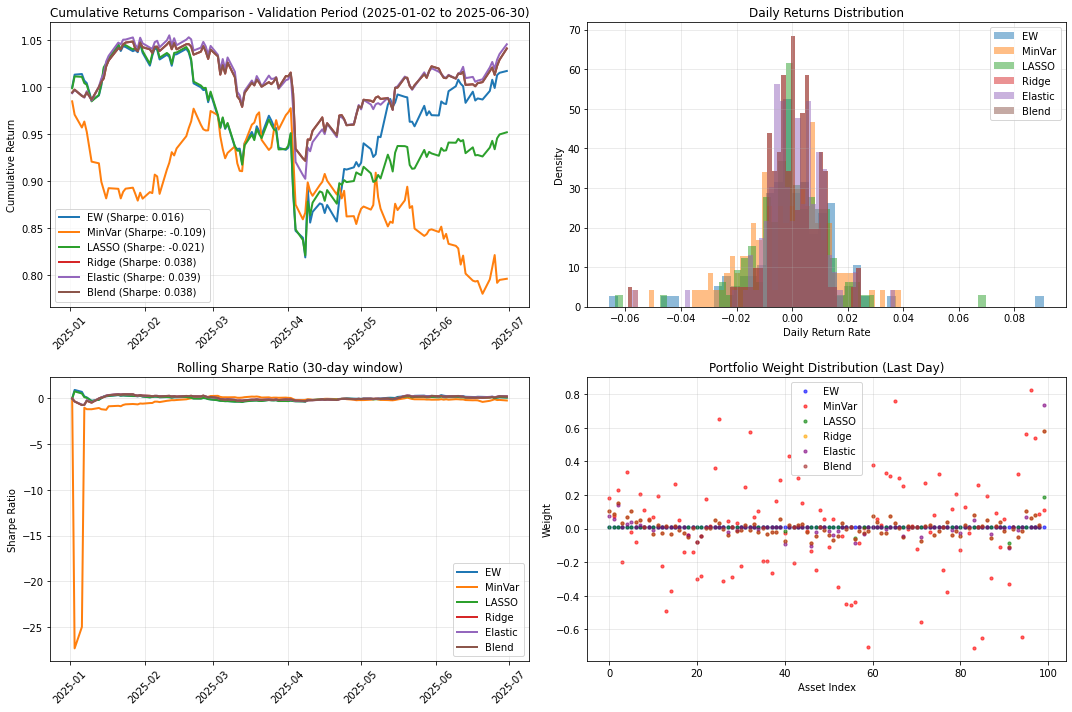

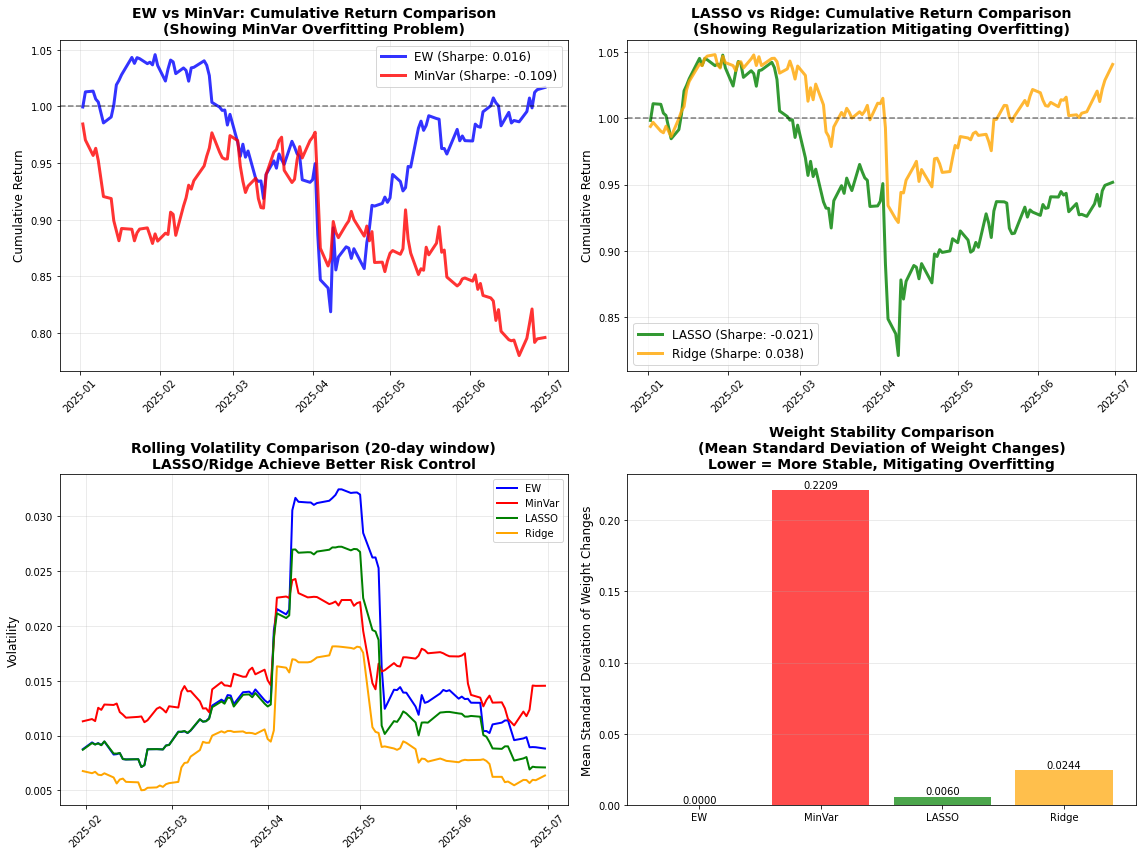


=== Best Portfolio (Based on Sharpe Ratio) ===
Portfolio: Elastic
Sharpe Ratio: 0.0388
Total Return: 0.0452
Mean Daily Return: 0.000422
Std Daily Return: 0.010870
Max Drawdown: 0.1446

=== Project Completed ===


In [9]:
if __name__ == "__main__":
    main()

/var/folders/br/3qz64fqj39dcr43t4p8kk74w0000gn/T/ipykernel_56776/2108197428.py:114: RuntimeWarning: invalid value encountered in scalar power
  ann_return = (growth[-1]**(252/len(ret)) - 1) if len(ret)>0 else 0.0



Validation 2025-01-02 → 2025-06-30 | WINDOW=126, LAGS=5, Assets=30
                DailySharpe  AnnSharpe  Ann.Return   Ann.Vol  Cum.Return      MaxDD
Strategy                                                                           
Huber              0.029913   0.474856   -0.975662 28.057304   -0.834517 -36.238375
Ridge              0.025038   0.397465   -0.979712 25.636371   -0.848475  -4.629107
Lasso              0.024996   0.396792   -0.965155 25.639584   -0.803116  -5.620411
EW                 0.008394   0.133257         NaN 25.963651   -1.000539  -1.367191
Pinball(τ=0.7)     0.005223   0.082917         NaN 26.442862   -1.000004  -1.014022


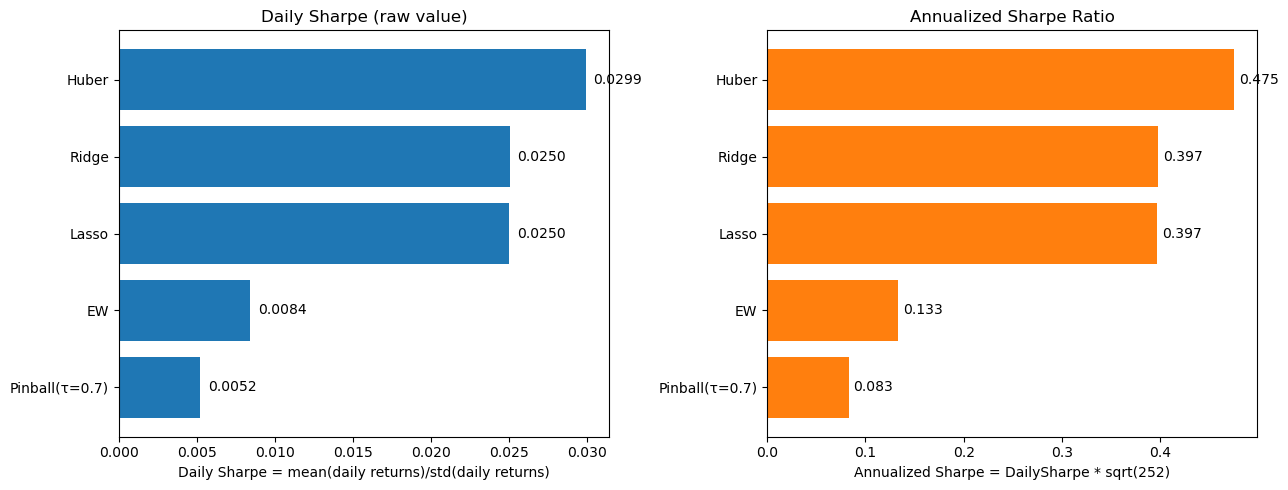

In [1]:
# ONE CELL: Rolling validation + raw daily Sharpe and annualized Sharpe ratio, table + plots
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.linear_model import Lasso, Ridge, HuberRegressor
try:
    from sklearn.linear_model import QuantileRegressor
    HAS_SK_QREG = True
except Exception:
    HAS_SK_QREG = False

# ----------------------- Config -----------------------
CSV_PATH      = "Final_cleaned.csv"
DATE_COL      = "Date"
VAL_START     = "2025-01-02"
VAL_END       = "2025-06-30"
WINDOW        = 126
N_LAGS        = 5
MAX_ASSETS    = 30                 # set None for all assets

ALPHA_LASSO   = 1e-3
ALPHA_RIDGE   = 1e-3
ALPHA_HUBER   = 1e-4
EPS_HUBER     = 1.35
ALPHA_PINBALL = 1e-4
TAU_PINBALL   = 0.7

# ---------------------- Load data ---------------------
df = pd.read_csv(CSV_PATH)
if DATE_COL not in df.columns:
    maybe = [c for c in df.columns if c.lower() == "date"]
    if maybe: df = df.rename(columns={maybe[0]: DATE_COL})
    else: raise KeyError("No 'Date' column found in CSV.")
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

asset_cols = [c for c in df.columns if c != DATE_COL]
if MAX_ASSETS is not None:
    asset_cols = asset_cols[:MAX_ASSETS]
R = df[asset_cols].astype(float).to_numpy()   # (T,P)
dates = df[DATE_COL].to_numpy()

# ----------------- helpers & features -----------------
def daily_sharpe(ret):
    # raw daily Sharpe = mean(daily returns) / std(daily returns)
    s = np.std(ret, ddof=1)
    return (np.mean(ret)/s) if s>0 else 0.0

def ann_sharpe_from_daily(ret, freq=252):
    return daily_sharpe(ret) * np.sqrt(freq)

def max_drawdown(cum):
    peak = np.maximum.accumulate(cum)
    return (cum/peak - 1.0).min()

def normalize_long_only(pred):
    pred = np.clip(pred, 0, None)
    s = pred.sum()
    return pred/s if s>1e-12 else np.ones_like(pred)/len(pred)

def make_xy(window_R, n_lags=N_LAGS):
    T, P = window_R.shape
    rows = T - n_lags
    X_list, Y = [], window_R[n_lags:, :]
    for j in range(P):
        xj = np.column_stack([window_R[n_lags-k-1:T-k-1, j] for k in range(n_lags)])
        X_list.append(xj)
    return X_list, Y  # per-asset lags; Y aligned

# ---------------- rolling backtest --------------------
mask = (dates >= np.datetime64(VAL_START)) & (dates <= np.datetime64(VAL_END))
val_idx = np.where(mask)[0]
if len(val_idx)==0: raise ValueError("No validation dates in the requested range.")

first_val_ix = val_idx[0]
if first_val_ix - WINDOW < N_LAGS:
    raise ValueError("Not enough history before validation start for WINDOW/N_LAGS.")

methods = ["EW", "Lasso", "Ridge", "Huber", f"Pinball(τ={TAU_PINBALL})"]
rets = {m: [] for m in methods}

def fit_predict_weights(window_R):
    T,P = window_R.shape
    X_list, Y = make_xy(window_R, N_LAGS)
    rows = Y.shape[0]
    x_last = [X_list[j][rows-1:rows, :] for j in range(P)]
    w_lasso = np.zeros(P); w_ridge = np.zeros(P); w_huber = np.zeros(P); w_qreg = np.zeros(P)
    for j in range(P):
        xtr, ytr, xte = X_list[j][:-1, :], Y[:-1, j], x_last[j]
        m = Lasso(alpha=ALPHA_LASSO, fit_intercept=True, max_iter=2000); m.fit(xtr,ytr); w_lasso[j]=m.predict(xte)[0]
        m = Ridge(alpha=ALPHA_RIDGE, fit_intercept=True);                 m.fit(xtr,ytr); w_ridge[j]=m.predict(xte)[0]
        m = HuberRegressor(alpha=ALPHA_HUBER, epsilon=EPS_HUBER);         m.fit(xtr,ytr); w_huber[j]=m.predict(xte)[0]
        if HAS_SK_QREG:
            m = QuantileRegressor(alpha=ALPHA_PINBALL, quantile=TAU_PINBALL, solver="highs"); m.fit(xtr,ytr); w_qreg[j]=m.predict(xte)[0]
        else:
            w_qreg[j] = w_huber[j]
    return {
        "EW": np.ones(P)/P,
        "Lasso": normalize_long_only(w_lasso),
        "Ridge": normalize_long_only(w_ridge),
        "Huber": normalize_long_only(w_huber),
        f"Pinball(τ={TAU_PINBALL})": normalize_long_only(w_qreg),
    }

for t in range(first_val_ix, val_idx[-1]+1):
    W = fit_predict_weights(R[t-WINDOW:t, :])
    r_t = R[t, :]
    for k,w in W.items():
        rets[k].append(float(np.dot(w, r_t)))

# ---------------- metrics table -----------------------
rows = []
for k in methods:
    ret = np.array(rets[k], dtype=float)
    growth = np.cumprod(1+ret) if len(ret)>0 else np.array([1.0])
    ann_return = (growth[-1]**(252/len(ret)) - 1) if len(ret)>0 else 0.0
    ann_vol = (np.std(ret, ddof=1)*np.sqrt(252)) if len(ret)>1 else 0.0
    raw_daily_sh = daily_sharpe(ret)          # raw daily Sharpe (mean/std)
    ann_sh = ann_sharpe_from_daily(ret)       # annualized Sharpe ratio
    rows.append({
        "Strategy": k,
        "DailySharpe": raw_daily_sh,
        "AnnSharpe": ann_sh,
        "Ann.Return": ann_return,
        "Ann.Vol": ann_vol,
        "Cum.Return": growth[-1]-1,
        "MaxDD": max_drawdown(growth)
    })

res_df = pd.DataFrame(rows).set_index("Strategy")
res_df = res_df.sort_values("AnnSharpe", ascending=False)  # sort by annualized Sharpe
pd.options.display.float_format = "{:0.6f}".format

print(f"\nValidation {VAL_START} → {VAL_END} | WINDOW={WINDOW}, LAGS={N_LAGS}, Assets={len(asset_cols)}")
print(res_df.to_string())

# ==================== PLOTS: two side-by-side bar charts ====================
fig, axes = plt.subplots(1,2, figsize=(13,5), gridspec_kw={"width_ratios":[1,1]})

# Left: raw daily Sharpe (labelled "Daily Sharpe (raw value)")
order = res_df.sort_values("DailySharpe", ascending=True)
axes[0].barh(order.index, order["DailySharpe"])
axes[0].set_title("Daily Sharpe (raw value)")
axes[0].set_xlabel("Daily Sharpe = mean(daily returns)/std(daily returns)")
for i,(s,v) in enumerate(zip(order.index, order["DailySharpe"])):
    axes[0].text(v + 0.0005*np.sign(v if v!=0 else 1), i, f"{v:.4f}", va="center")

# Right: annualized Sharpe ratio (labelled clearly)
order2 = res_df.sort_values("AnnSharpe", ascending=True)
axes[1].barh(order2.index, order2["AnnSharpe"], color="tab:orange")
axes[1].set_title("Annualized Sharpe Ratio")
axes[1].set_xlabel("Annualized Sharpe = DailySharpe * sqrt(252)")
for i,(s,v) in enumerate(zip(order2.index, order2["AnnSharpe"])):
    axes[1].text(v + 0.005*np.sign(v if v!=0 else 1), i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()


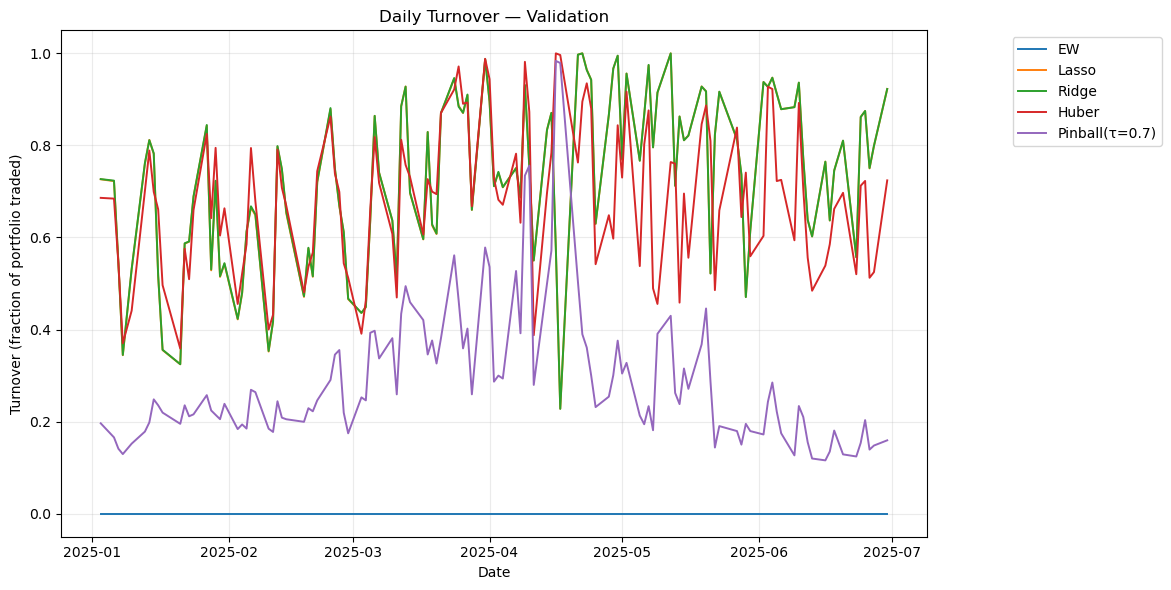


Validation turnover summary:
                AvgTurnover  MedTurnover  StdTurnover  NumRebalances  TotalTradedFraction
Strategy                                                                                 
Ridge              0.729465     0.750260     0.176778            121            88.265297
Lasso              0.728971     0.748747     0.177012            121            88.205488
Huber              0.685094     0.695419     0.156816            121            82.896361
Pinball(τ=0.7)     0.290759     0.244275     0.154128            121            35.181792
EW                 0.000000     0.000000     0.000000              0             0.000000

Saved turnover plot to: /Users/hrithikkannankrishnan/Desktop/DBA5106 - Foundations of BA/plots/validation_turnover.png
Saved summary CSV to: /Users/hrithikkannankrishnan/Desktop/DBA5106 - Foundations of BA/validation_turnover_table.csv


In [4]:
# ONE CELL: compute daily weights during validation, plot daily turnover, and save summary table.
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import Lasso, Ridge, HuberRegressor
try:
    from sklearn.linear_model import QuantileRegressor
    HAS_QREG = True
except Exception:
    HAS_QREG = False

OUT = Path("plots"); OUT.mkdir(exist_ok=True)
CSV_OUT = Path("validation_turnover_table.csv")

# ---------------- Config ----------------
CSV_PATH   = "Final_cleaned.csv"
DATE_COL   = "Date"
VAL_START  = "2025-01-02"
VAL_END    = "2025-06-30"
WINDOW     = 126
N_LAGS     = 5
MAX_ASSETS = None   # set to int for speed, or None for all assets

ALPHA_LASSO   = 1e-3
ALPHA_RIDGE   = 1e-3
ALPHA_HUBER   = 1e-4
EPS_HUBER     = 1.35
ALPHA_PINBALL = 1e-4
TAU_PINBALL   = 0.7

# ---------------- Load data ----------------
df = pd.read_csv(CSV_PATH)
if DATE_COL not in df.columns:
    maybe = [c for c in df.columns if c.lower() == "date"]
    if maybe:
        df = df.rename(columns={maybe[0]: DATE_COL})
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.reset_index().rename(columns={"index": DATE_COL})
    else:
        raise KeyError("No Date column found in CSV.")
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

asset_cols = [c for c in df.columns if c != DATE_COL]
if MAX_ASSETS is not None:
    asset_cols = asset_cols[:MAX_ASSETS]
R = df[asset_cols].astype(float).to_numpy()  # (T, P)
dates = df[DATE_COL].to_numpy()

# ---------------- helpers ----------------
def normalize_long_only(v):
    v = np.clip(v, 0.0, None)
    s = v.sum()
    return v / s if s > 1e-12 else np.ones_like(v) / len(v)

def make_xy(window_R, n_lags=N_LAGS):
    T, P = window_R.shape
    rows = T - n_lags
    X_list = []
    Y = window_R[n_lags:, :]
    for j in range(P):
        xj = np.column_stack([window_R[n_lags - k - 1:T - k - 1, j] for k in range(n_lags)])
        X_list.append(xj)
    return X_list, Y

# ---------------- rolling weight construction ----------------
mask = (dates >= np.datetime64(VAL_START)) & (dates <= np.datetime64(VAL_END))
val_idx = np.where(mask)[0]
if len(val_idx) == 0:
    raise ValueError("No validation dates in range.")

first_val_ix = val_idx[0]
if first_val_ix - WINDOW < N_LAGS:
    raise ValueError("Not enough history before validation start for WINDOW/N_LAGS.")

P = R.shape[1]
methods = ["EW", "Lasso", "Ridge", "Huber", f"Pinball(τ={TAU_PINBALL})"]

# initialize storage for daily weight matrices: dict -> list of (P,) arrays
weights = {m: [] for m in methods}
val_dates = []

for t in range(first_val_ix, val_idx[-1] + 1):
    window_R = R[t - WINDOW:t, :]  # (WINDOW, P)
    X_list, Y = make_xy(window_R, N_LAGS)
    rows = Y.shape[0]
    if rows < 2:
        # cannot train models reliably; fallback to EW for that day
        W = {m: np.ones(P) / P for m in methods}
    else:
        # prepare last-step features
        x_last = [X_list[j][rows - 1: rows, :] for j in range(P)]
        w_lasso = np.zeros(P); w_ridge = np.zeros(P); w_huber = np.zeros(P); w_q = np.zeros(P)
        for j in range(P):
            xtr = X_list[j][:-1, :]
            ytr = Y[:-1, j]
            xte = x_last[j]
            # Lasso
            try:
                m = Lasso(alpha=ALPHA_LASSO, fit_intercept=True, max_iter=2000).fit(xtr, ytr)
                w_lasso[j] = float(m.predict(xte)[0])
            except Exception:
                w_lasso[j] = 0.0
            # Ridge
            try:
                m = Ridge(alpha=ALPHA_RIDGE, fit_intercept=True).fit(xtr, ytr)
                w_ridge[j] = float(m.predict(xte)[0])
            except Exception:
                w_ridge[j] = 0.0
            # Huber
            try:
                m = HuberRegressor(alpha=ALPHA_HUBER, epsilon=EPS_HUBER).fit(xtr, ytr)
                w_huber[j] = float(m.predict(xte)[0])
            except Exception:
                w_huber[j] = 0.0
            # Pinball / Quantile
            if HAS_QREG:
                try:
                    m = QuantileRegressor(alpha=ALPHA_PINBALL, quantile=TAU_PINBALL, solver="highs").fit(xtr, ytr)
                    w_q[j] = float(m.predict(xte)[0])
                except Exception:
                    w_q[j] = 0.0
            else:
                # fallback proxy: use huber pred if Quantile not available
                w_q[j] = w_huber[j]

        W = {
            "EW": np.ones(P) / P,
            "Lasso": normalize_long_only(w_lasso),
            "Ridge": normalize_long_only(w_ridge),
            "Huber": normalize_long_only(w_huber),
            f"Pinball(τ={TAU_PINBALL})": normalize_long_only(w_q),
        }

    for mname in methods:
        weights[mname].append(np.asarray(W[mname], dtype=float))
    val_dates.append(dates[t])

# ---------------- compute daily turnover ----------------
# turnover_t for day i corresponds to change from day i-1 -> i; first day set to NaN
turn_df = pd.DataFrame(index=pd.to_datetime(val_dates))
summary_rows = []

for mname in methods:
    arr = np.vstack(weights[mname])            # shape (n_days, P)
    diffs = np.abs(np.diff(arr, axis=0))      # shape (n_days-1, P)
    daily_turn = 0.5 * diffs.sum(axis=1)      # length n_days-1
    # prepend NaN to align with val_dates length
    daily_full = np.concatenate(([np.nan], daily_turn))
    turn_df[mname] = daily_full

    # summary stats
    nonnan = ~np.isnan(daily_full)
    arr_nonan = daily_full[nonnan]
    avg = float(np.nanmean(arr_nonan)) if arr_nonan.size else np.nan
    med = float(np.nanmedian(arr_nonan)) if arr_nonan.size else np.nan
    std = float(np.nanstd(arr_nonan, ddof=1)) if arr_nonan.size>1 else np.nan
    num_reb = int(np.sum(arr_nonan > 1e-8)) if arr_nonan.size else 0
    total_traded = float(np.nansum(arr_nonan)) if arr_nonan.size else 0.0
    summary_rows.append({
        "Strategy": mname,
        "AvgTurnover": avg,
        "MedTurnover": med,
        "StdTurnover": std,
        "NumRebalances": num_reb,
        "TotalTradedFraction": total_traded
    })

summary_df = pd.DataFrame(summary_rows).set_index("Strategy").sort_values("AvgTurnover", ascending=False)

# ---------------- plot daily turnover ----------------
plt.figure(figsize=(12,6))
for col in turn_df.columns:
    plt.plot(turn_df.index, turn_df[col], label=col, linewidth=1.4)
plt.legend(loc="upper right", bbox_to_anchor=(1.28,1))
plt.title("Daily Turnover — Validation")
plt.xlabel("Date")
plt.ylabel("Turnover (fraction of portfolio traded)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(OUT / "validation_turnover.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------------- save & print summary ----------------
summary_df.to_csv(CSV_OUT, float_format="%.8f")
print("\nValidation turnover summary:")
print(summary_df.to_string())
print("\nSaved turnover plot to:", (OUT / "validation_turnover.png").resolve())
print("Saved summary CSV to:", CSV_OUT.resolve())
